In [2]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath("../../"))

from utils.evaluate_alerting import evaluate_alert_hitrate, summarize_alert_hitrate

In [4]:
DATA_PATH = "../../data/vitals_data"

top_dir = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
df = None
for t in top_dir:
    df_i = pd.read_parquet(f"{DATA_PATH}/mimic_vitals_p0{t}.parquet")
    if df is None:
        df = df_i
    else:
        df = pd.concat([df, df_i])

In [3]:
len(df["Record"].unique())

11105

In [4]:
sampled_records = np.load(f"{DATA_PATH}/../test_records.npy", allow_pickle=True)
sampled_df = df[df["Record"].isin(sampled_records)]
len(sampled_df['Record'].unique())

2000

  p000109-2142-01-18-16-05n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p000515-2162-07-01-10-44n | Failed: 2-th leading minor of the array is not positive definite
  p000518-2109-03-26-14-23n | Failed: 2-th leading minor of the array is not positive definite
  p001028-2168-03-09-15-41n | lag=4 | AIC=1.2
    HR | MAE=3.047 | MAPE=3.856 | RMSE=3.123
    RESP | MAE=2.372 | MAPE=9.414 | RMSE=2.670
    SpO2 | MAE=1.637 | MAPE=1.652 | RMSE=1.779


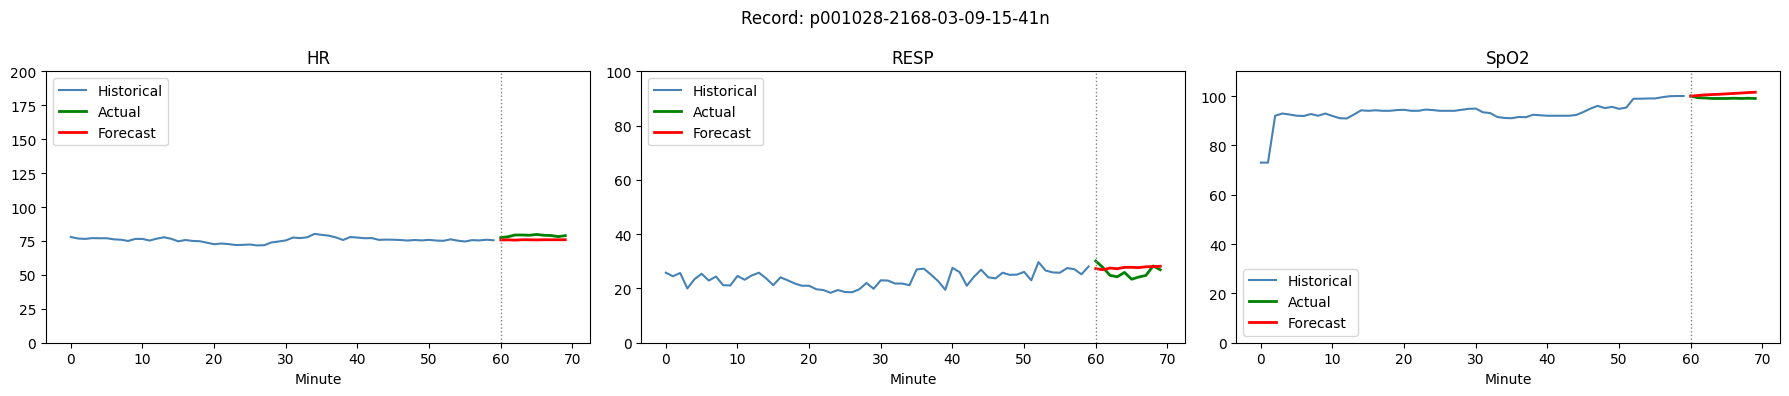

  p001453-2151-02-25-16-04n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p001824-2163-10-11-12-42n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p001949-2128-03-30-21-16n | Failed: 2-th leading minor of the array is not positive definite
  p002014-2177-03-14-12-07n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p002067-2191-03-09-14-58n | lag=2 | AIC=3.0
    HR | MAE=0.849 | MAPE=1.192 | RMSE=1.024
    RESP | MAE=2.748 | MAPE=11.774 | RMSE=3.044
    SpO2 | MAE=0.356 | MAPE=0.363 | RMSE=0.435


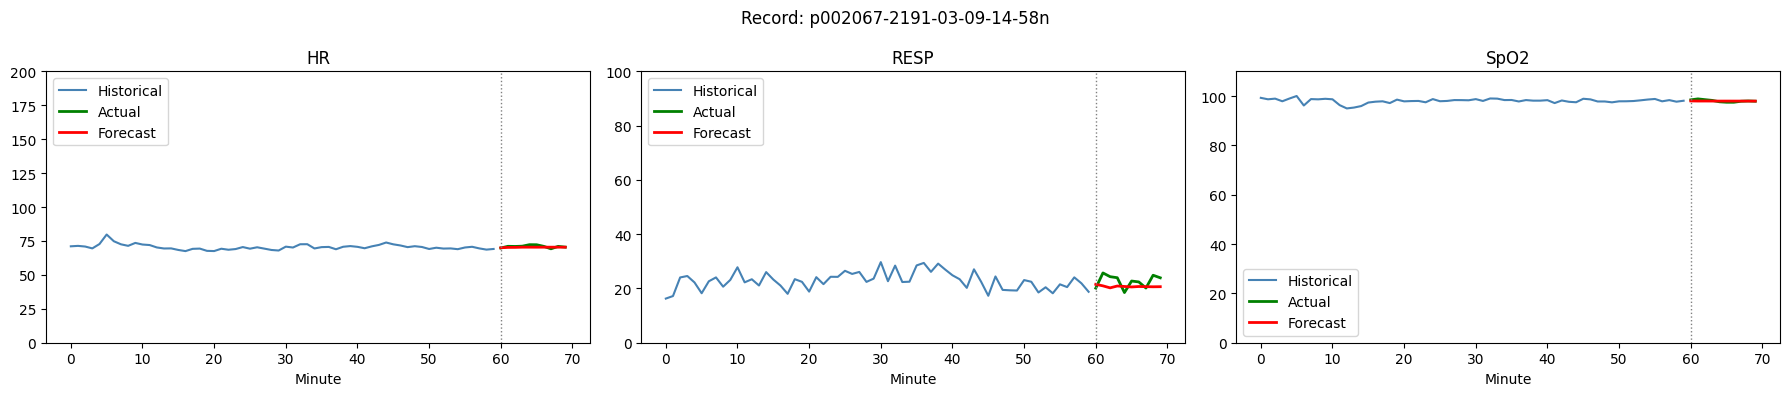

  p002185-2159-10-18-12-17n | Failed: 3-th leading minor of the array is not positive definite
  p002700-2199-11-26-03-05n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p002990-2153-05-26-13-09n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p002990-2153-05-27-15-06n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p003214-2164-08-17-19-20n | lag=1 | AIC=4.0
    HR | MAE=3.755 | MAPE=3.283 | RMSE=4.388
    RESP | MAE=2.096 | MAPE=10.691 | RMSE=2.563
    SpO2 | MAE=1.277 | MAPE=1.356 | RMSE=1.804


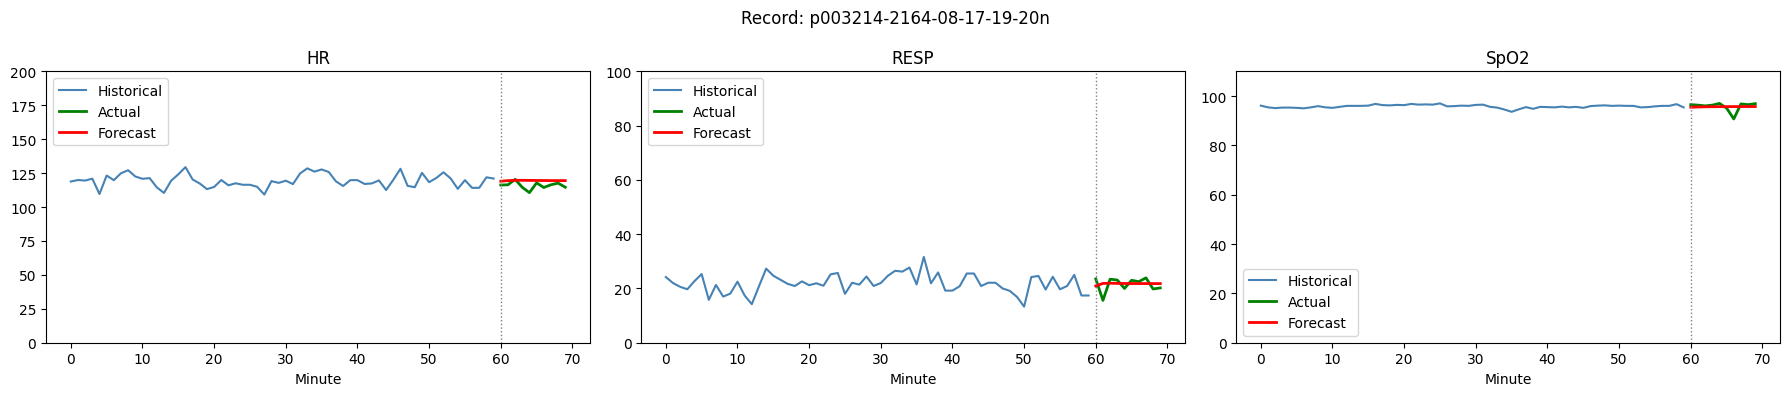

  p003866-2134-10-12-12-04n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p004109-2132-11-21-15-41n | Failed: 3-th leading minor of the array is not positive definite
  p004113-2142-08-16-12-14n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p004348-2137-10-04-17-12n | lag=1 | AIC=3.4
    HR | MAE=1.256 | MAPE=1.955 | RMSE=1.426
    RESP | MAE=0.124 | MAPE=0.812 | RMSE=0.290
    SpO2 | MAE=2.541 | MAPE=2.541 | RMSE=2.571


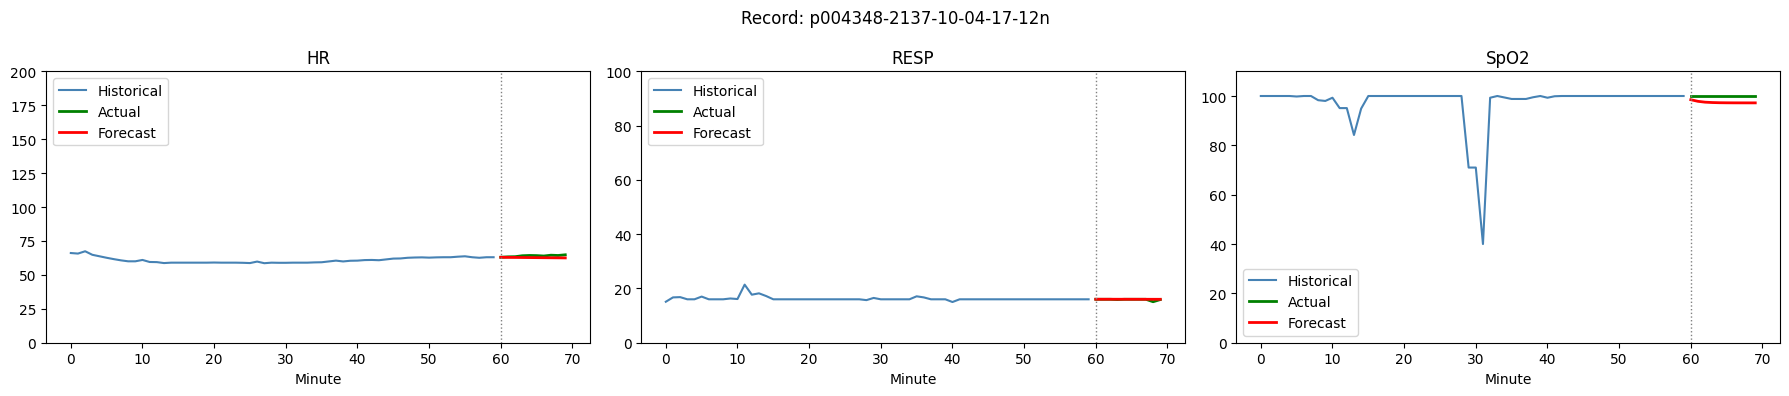

  p004593-2199-04-25-16-32n | Failed: 3-th leading minor of the array is not positive definite
  p004633-2118-06-03-12-22n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p004807-2122-09-01-09-12n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p005199-2204-09-27-11-58n | Failed: 2-th leading minor of the array is not positive definite
  p005400-2188-03-30-16-19n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p005786-2122-10-25-01-12n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p005885-2195-05-14-14-43n | lag=1 | AIC=-0.8
    HR | MAE=0.660 | MAPE=0.701 | RMSE=0.777
    RESP | MAE=2.084 | MAPE=6.733 | RMSE=2.402
    SpO2 | MAE=0.234 | MAPE=0.234 | RMSE=0.253


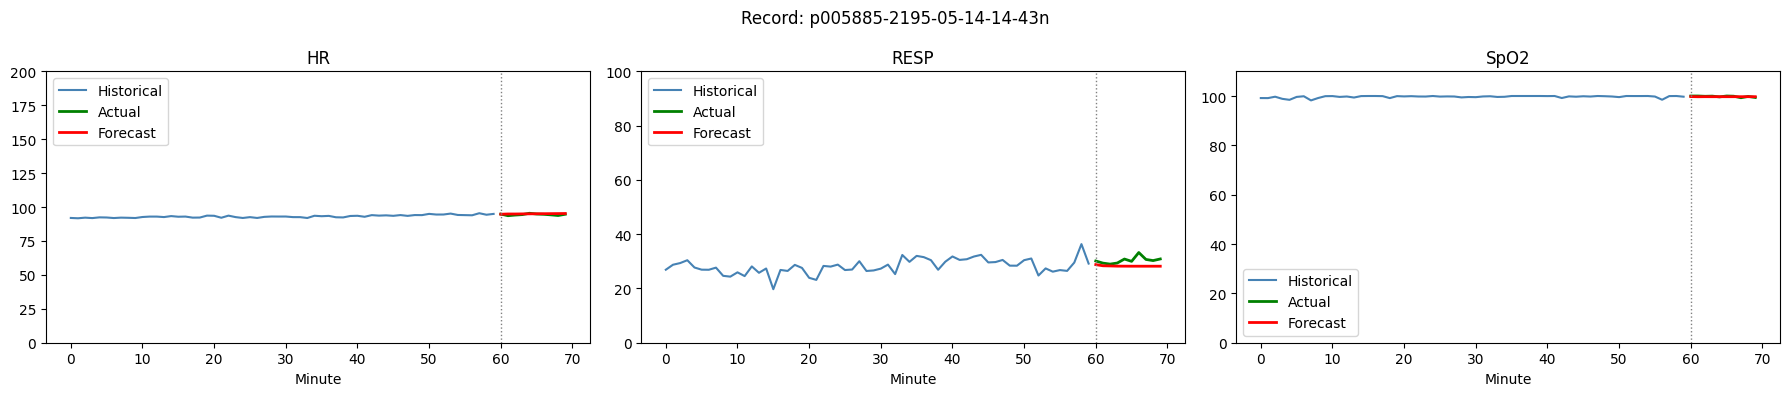

  p006539-2171-12-15-23-40n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p006708-2150-05-28-06-59n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p006889-2182-12-27-11-29n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p006958-2190-03-23-10-42n | Failed: 3-th leading minor of the array is not positive definite
  p007213-2109-12-19-12-10n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p007389-2124-09-17-20-45n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p007468-2194-09-20-13-50n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='

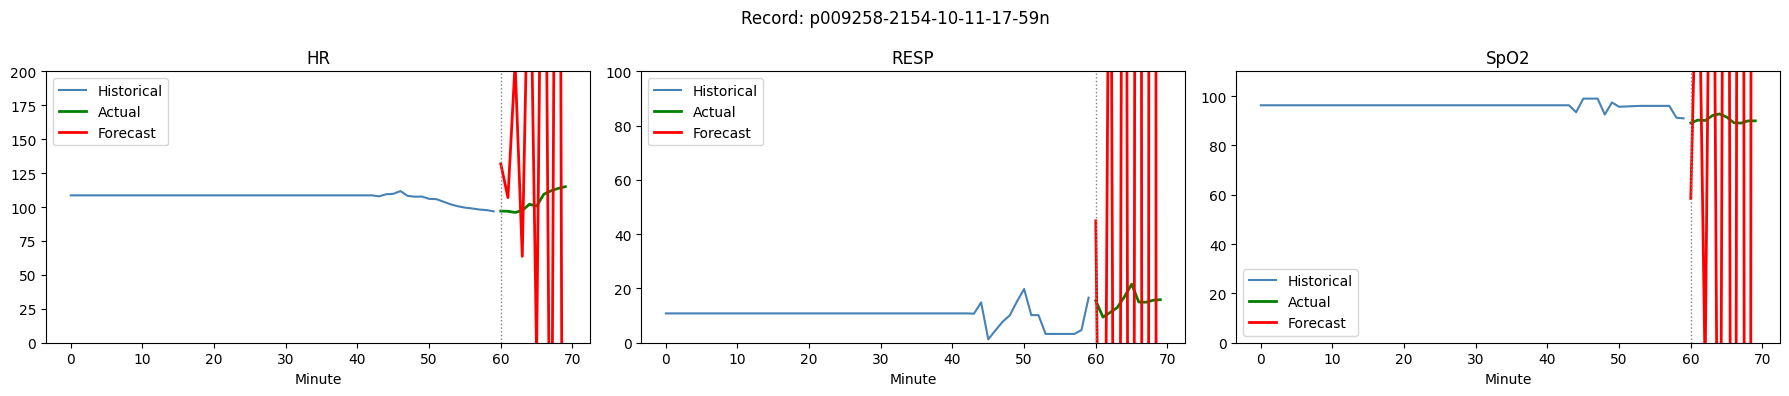

  p009295-2113-02-09-15-59n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p009425-2178-03-09-14-36n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p009460-2155-11-26-11-54n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p009847-2200-10-31-13-11n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p009889-2192-01-13-16-38n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p010205-2163-07-12-11-38n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p010611-2131-07-16-10-49n | Failed: x contains one or more constant column

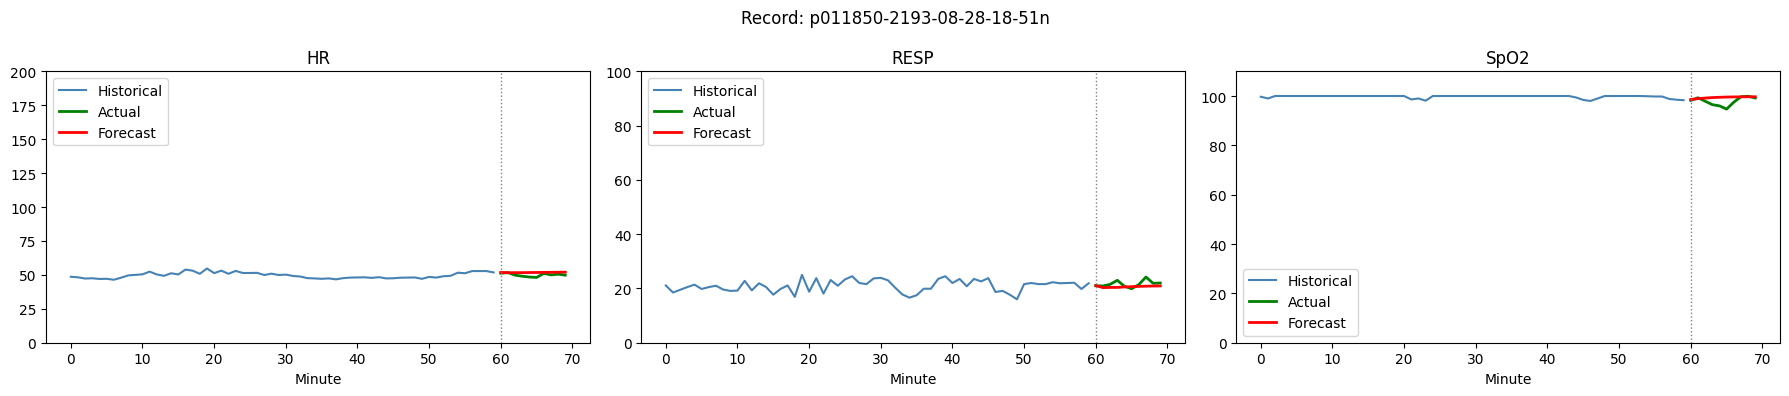

  p011945-2115-05-15-13-54n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012008-2172-09-19-12-57n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012212-2101-07-31-17-57n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012306-2165-06-16-14-53n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012344-2122-02-14-08-49n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012435-2136-12-12-10-51n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p012581-2106-02-23-21-55n | Failed: 3-th leading minor of the array is not

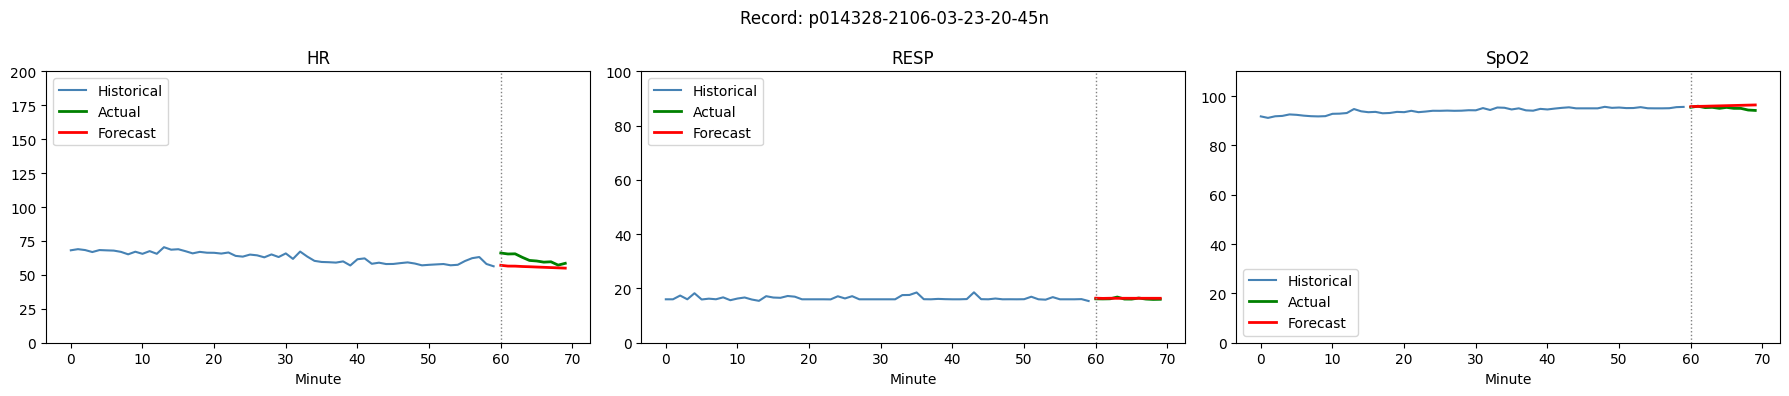

  p014898-2160-10-16-18-17n | Failed: 3-th leading minor of the array is not positive definite
  p015465-2129-12-09-20-56n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p015583-2159-05-15-20-31n | Failed: x contains one or more constant columns. Column(s) 0 are constant. Adding a constant with trend='c' is not allowed.
  p015883-2174-08-21-18-22n | Failed: 3-th leading minor of the array is not positive definite
  p015885-2133-11-16-12-23n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p016286-2122-10-04-07-41n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p016373-2199-02-19-07-14n | Failed: 2-th leading minor of the array is not positive definite
  p016399-2179-09-03-16-51n | Failed: 3-th leading minor of the array is not positive definite
  p0

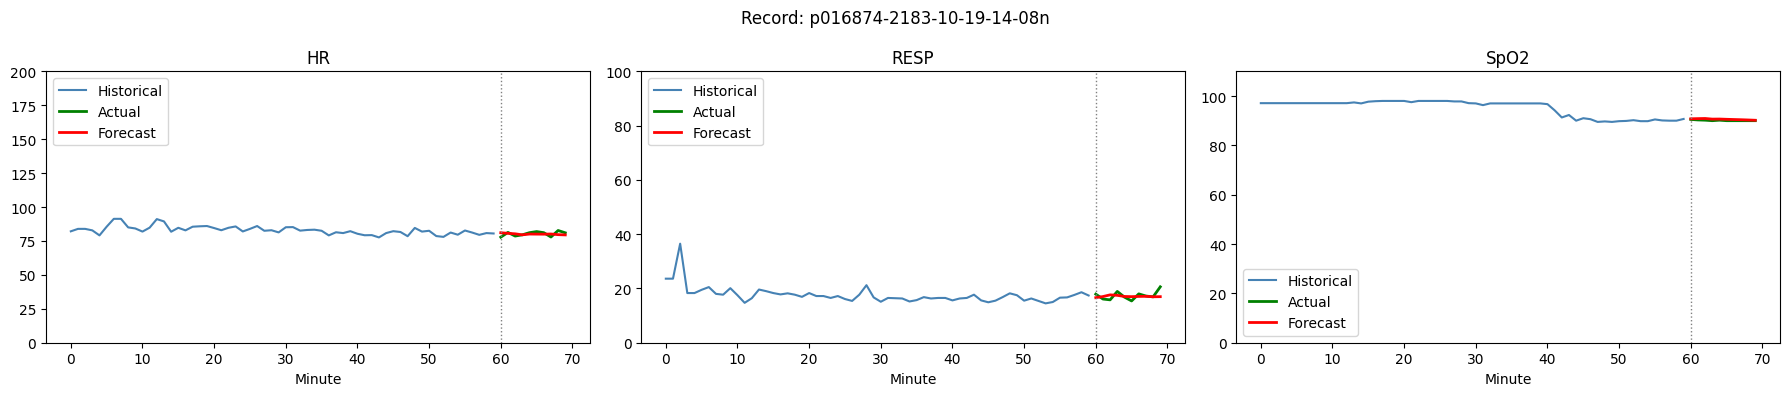

  p016961-2112-11-02-17-15n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p017054-2115-04-20-09-59n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p017440-2144-04-08-21-21n | Failed: 2-th leading minor of the array is not positive definite
  p017727-2197-10-22-11-15n | Failed: 2-th leading minor of the array is not positive definite
  p017997-2124-07-09-00-48n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p018248-2174-09-12-12-07n | lag=2 | AIC=-1.2
    HR | MAE=0.678 | MAPE=0.894 | RMSE=0.696
    RESP | MAE=1.825 | MAPE=9.890 | RMSE=2.111
    SpO2 | MAE=0.347 | MAPE=0.351 | RMSE=0.396


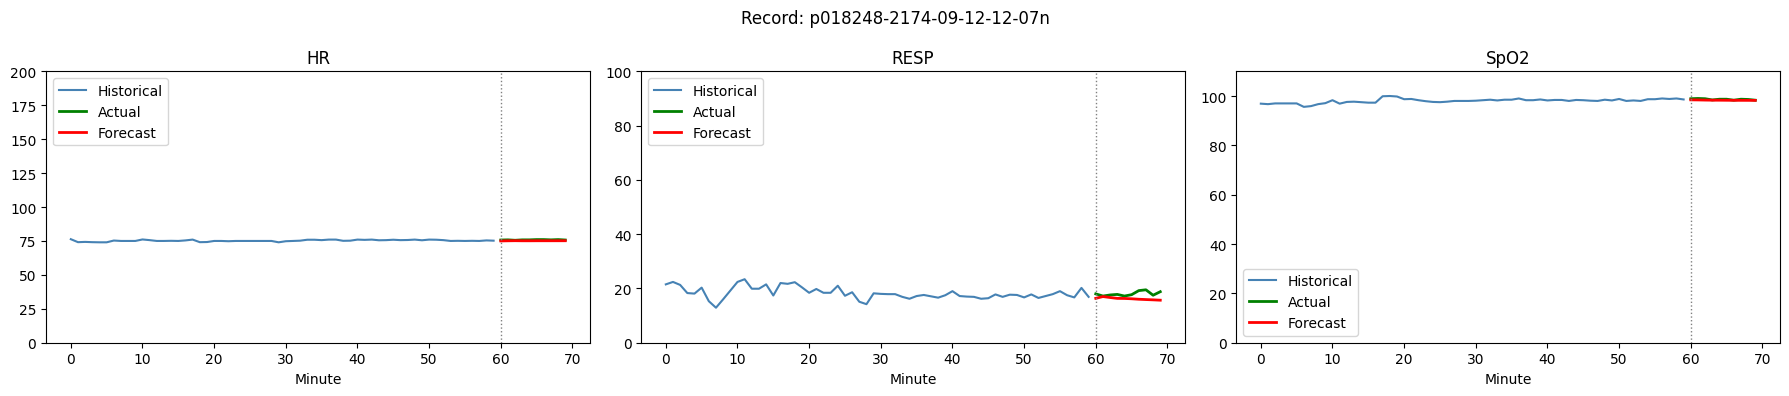

  p018413-2109-07-18-14-59n | Failed: x contains one or more constant columns. Column(s) 11 are constant. Adding a constant with trend='c' is not allowed.
  p018739-2136-08-21-05-04n | Failed: x contains one or more constant columns. Column(s) 0 are constant. Adding a constant with trend='c' is not allowed.
  p018739-2140-05-10-21-45n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p018971-2152-10-31-16-17n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p018998-2132-09-12-13-21n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p019208-2138-10-03-21-25n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p019371-2196-04-05-09-31n | lag=1 | AIC=0.4
    HR | MAE=2.897 | MAPE=2.9

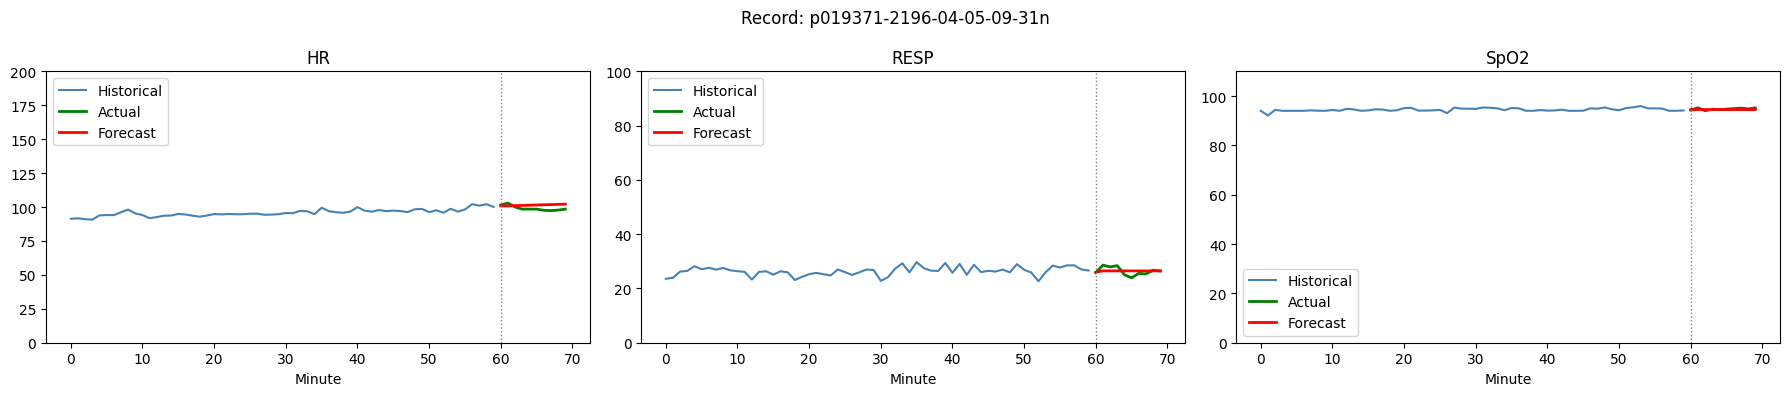

  p019430-2179-09-01-14-40n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p019771-2117-12-10-12-16n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p019866-2164-11-30-20-39n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p020354-2181-08-03-17-22n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p020474-2191-05-25-14-14n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p020940-2136-04-03-19-21n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p021265-2152-07-21-12-21n | Failed: x contains one or more constant column

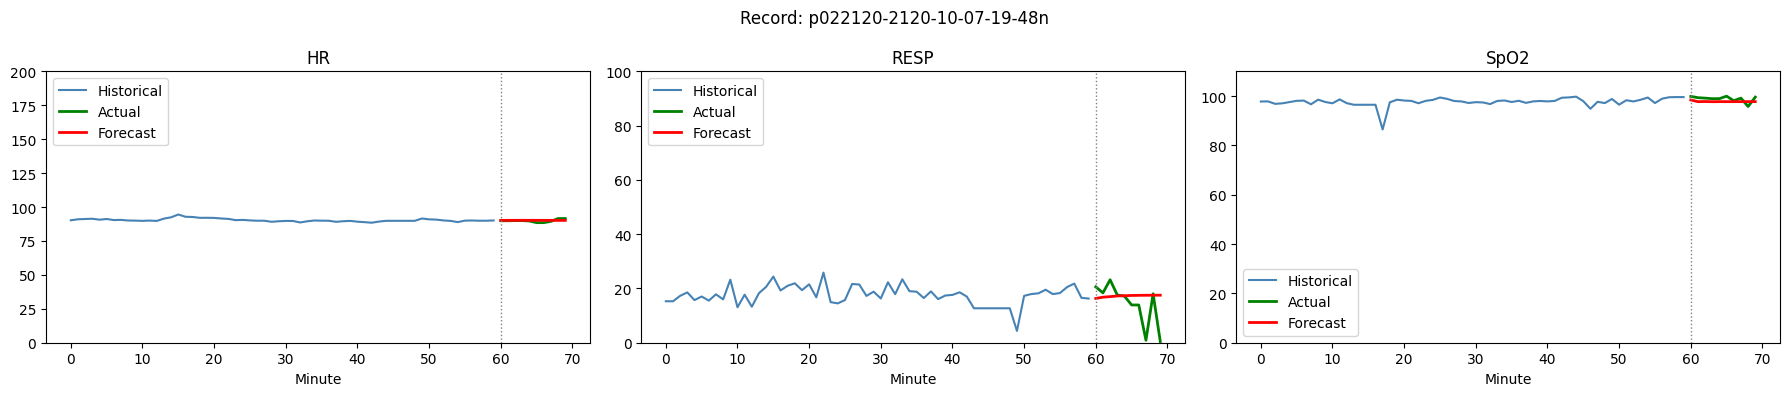

  p022306-2137-10-18-16-49n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p022336-2174-01-03-09-43n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p022603-2104-02-18-12-15n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p022687-2116-09-23-14-42n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p023097-2184-12-09-12-34n | lag=1 | AIC=-0.1
    HR | MAE=0.841 | MAPE=1.173 | RMSE=0.988
    RESP | MAE=1.825 | MAPE=11.405 | RMSE=2.496
    SpO2 | MAE=0.337 | MAPE=0.357 | RMSE=0.427


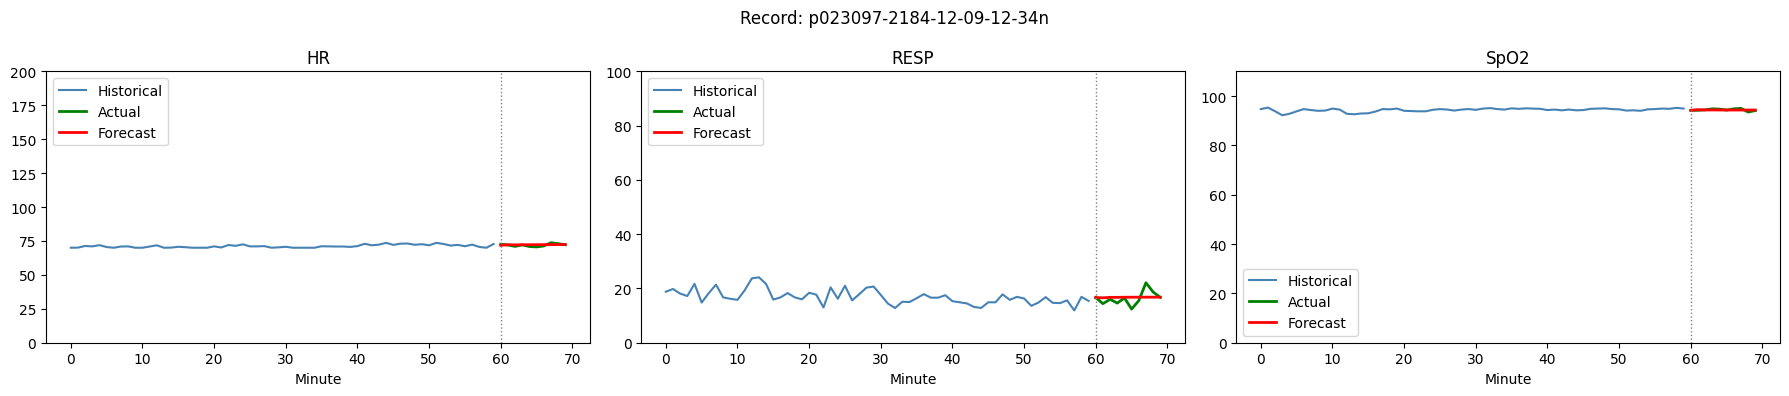

  p023126-2163-03-28-16-43n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p023321-2166-10-22-15-41n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p024446-2111-11-10-11-08n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p024508-2195-10-26-19-08n | lag=4 | AIC=0.4
    HR | MAE=1.434 | MAPE=1.883 | RMSE=1.525
    RESP | MAE=24.122 | MAPE=99.384 | RMSE=26.112
    SpO2 | MAE=0.182 | MAPE=0.186 | RMSE=0.193


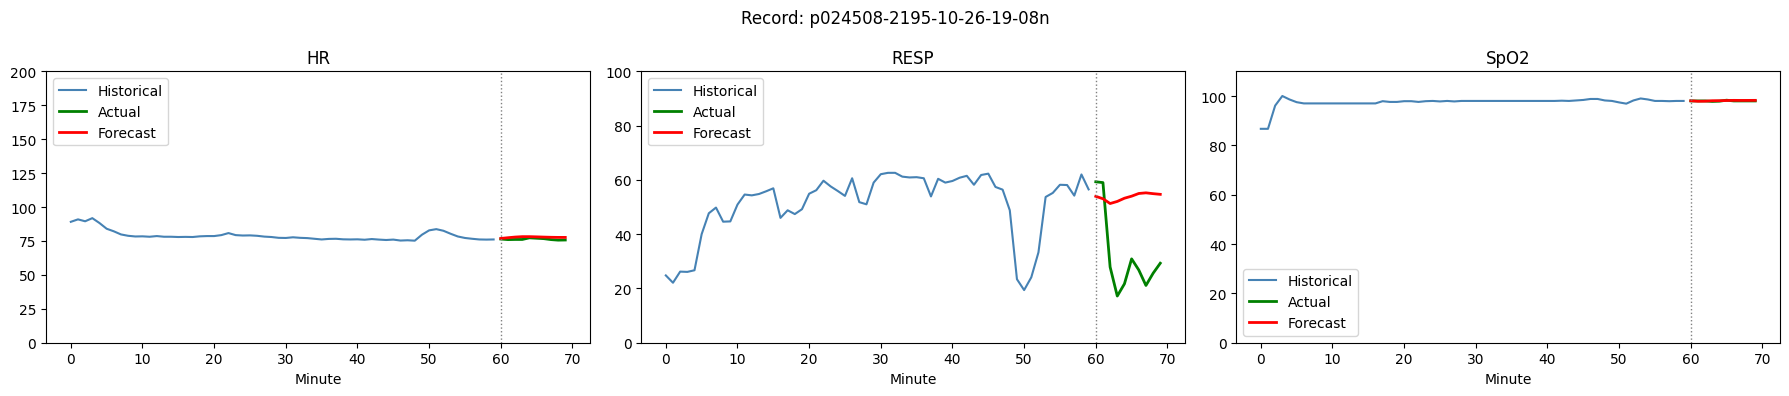

  p024597-2178-03-17-16-10n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p024902-2198-08-27-21-12n | Failed: 2-th leading minor of the array is not positive definite
  p024922-2164-11-14-10-50n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p025174-2148-03-14-16-36n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p025757-2199-04-01-20-01n | lag=2 | AIC=2.8
    HR | MAE=1.218 | MAPE=1.349 | RMSE=1.314
    RESP | MAE=0.592 | MAPE=8.126 | RMSE=0.778
    SpO2 | MAE=0.268 | MAPE=0.272 | RMSE=0.325


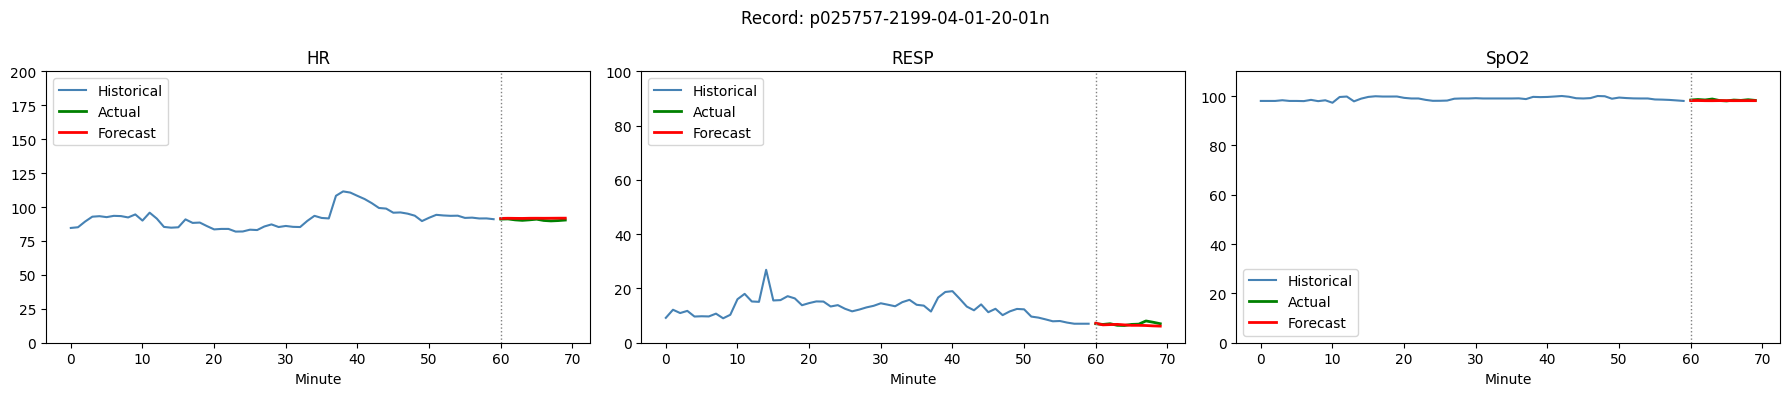

  p025858-2127-04-03-17-26n | Failed: 2-th leading minor of the array is not positive definite
  p026519-2188-09-16-13-40n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p026711-2113-07-07-12-22n | lag=3 | AIC=7.4
    HR | MAE=9.692 | MAPE=8.078 | RMSE=10.407
    RESP | MAE=1.471 | MAPE=6.293 | RMSE=1.951
    SpO2 | MAE=2.408 | MAPE=2.440 | RMSE=2.511


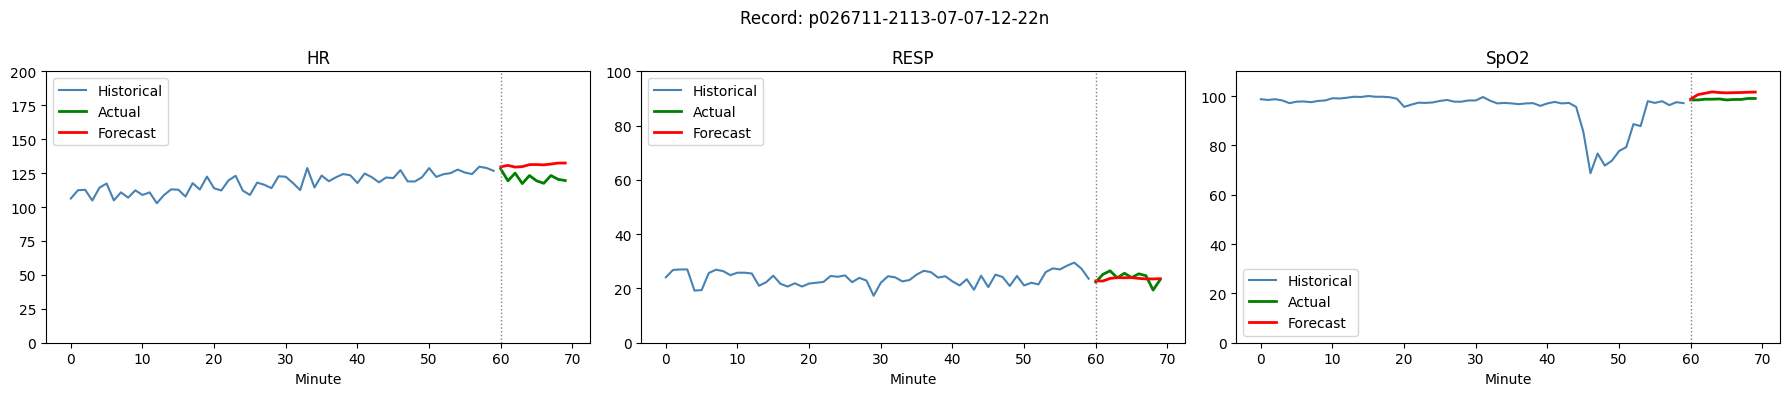

  p028187-2109-04-01-14-12n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p028281-2125-12-22-01-46n | lag=1 | AIC=4.7
    HR | MAE=4.252 | MAPE=3.582 | RMSE=4.899
    RESP | MAE=3.339 | MAPE=13.074 | RMSE=3.749
    SpO2 | MAE=0.884 | MAPE=0.896 | RMSE=1.058


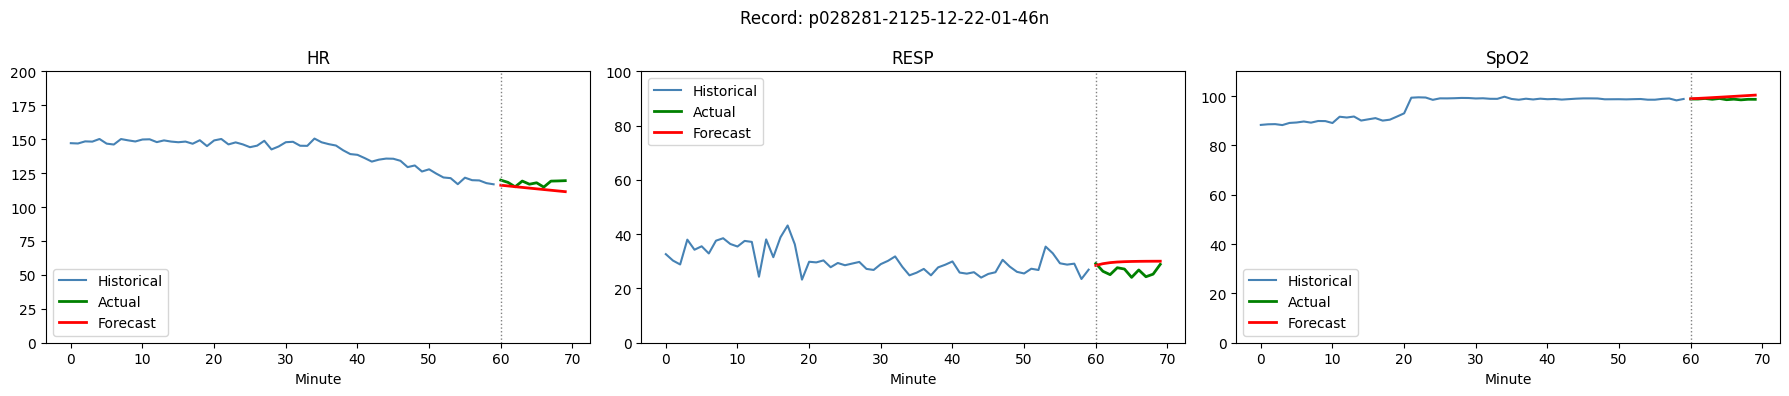

  p028510-2140-03-21-13-15n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p029216-2130-09-11-18-47n | Failed: x contains one or more constant columns. Column(s) 0 are constant. Adding a constant with trend='c' is not allowed.
  p030047-2154-02-15-16-48n | lag=1 | AIC=2.5
    HR | MAE=1.626 | MAPE=1.891 | RMSE=1.664
    RESP | MAE=1.634 | MAPE=6.964 | RMSE=1.911
    SpO2 | MAE=0.443 | MAPE=0.443 | RMSE=0.447


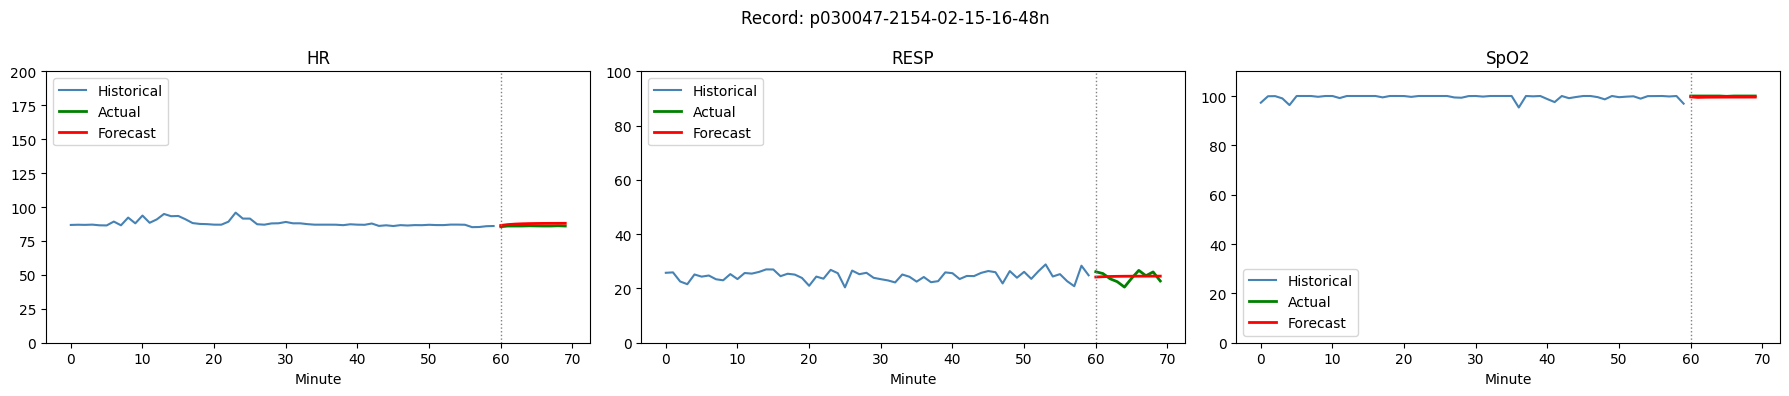

  p030542-2135-10-18-17-22n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p031191-2196-04-20-14-11n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p032247-2122-01-20-15-13n | lag=2 | AIC=0.0
    HR | MAE=2.071 | MAPE=1.816 | RMSE=2.303
    RESP | MAE=2.592 | MAPE=7.805 | RMSE=3.278
    SpO2 | MAE=1.267 | MAPE=1.275 | RMSE=1.346


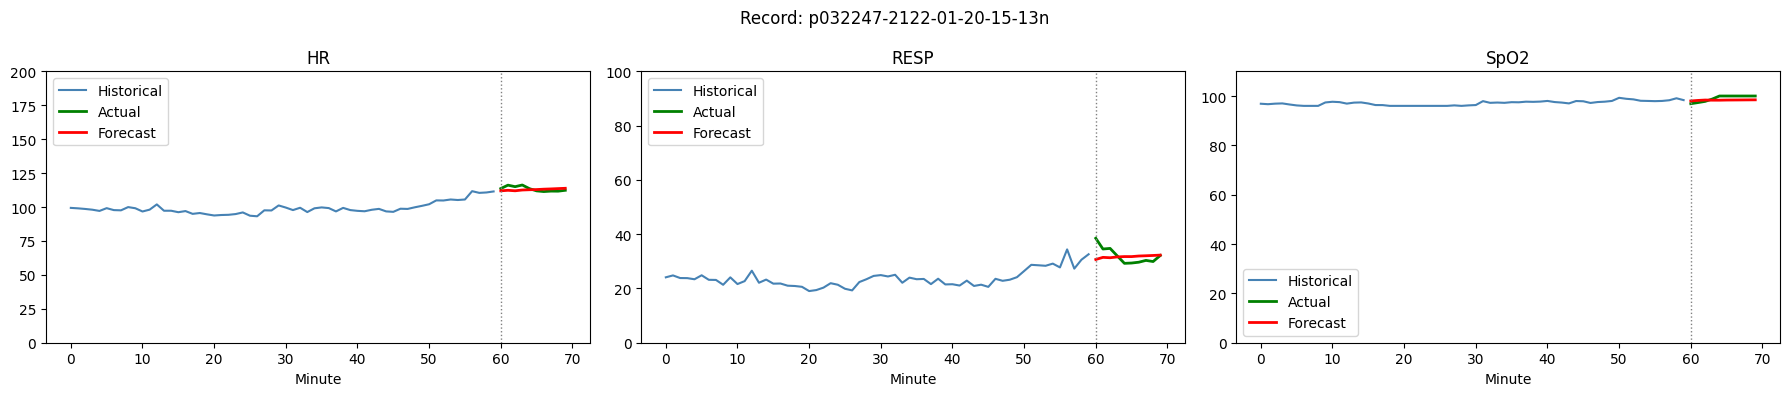

  p040057-2138-04-20-01-07n | Failed: 3-th leading minor of the array is not positive definite
  p040694-2126-01-16-16-09n | Failed: 2-th leading minor of the array is not positive definite
  p041405-2119-05-02-00-54n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p041768-2116-06-29-20-18n | lag=4 | AIC=2.4
    HR | MAE=4.626 | MAPE=7.371 | RMSE=5.288
    RESP | MAE=0.805 | MAPE=4.598 | RMSE=1.397
    SpO2 | MAE=0.499 | MAPE=0.512 | RMSE=0.596


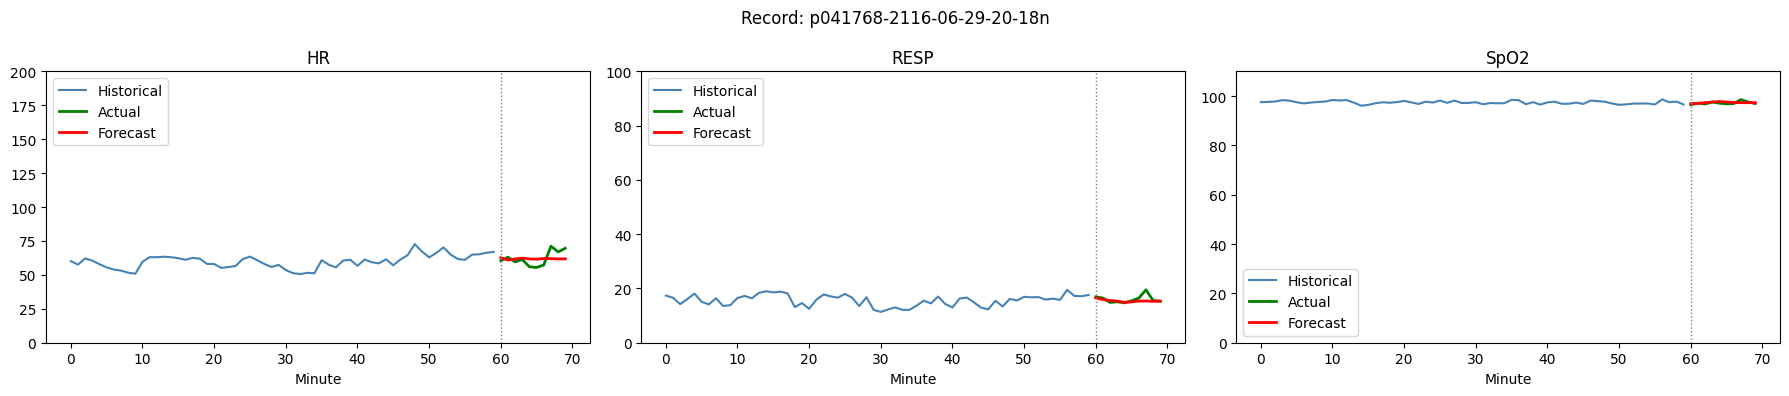

  p041902-2103-08-30-10-50n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p042970-2149-09-17-11-29n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p043484-2166-07-11-13-07n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p043737-2111-12-10-10-43n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p044061-2136-08-15-20-37n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p044255-2145-09-29-13-40n | lag=1 | AIC=2.2
    HR | MAE=0.696 | MAPE=0.765 | RMSE=0.913
    RESP | MAE=1.956 | MAPE=8.690 | RMSE=2.444
    SpO2 | MAE=0.911 | MAPE=0.920 | RMSE=0.993


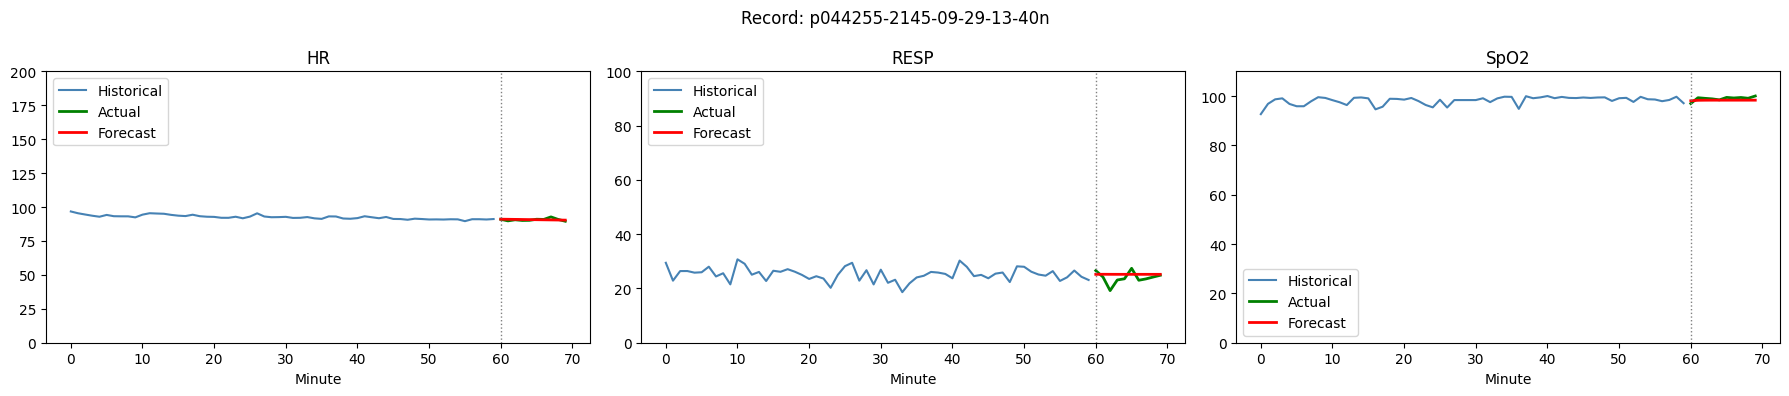

  p044781-2146-11-25-03-19n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p044789-2128-07-07-13-28n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p046695-2113-06-24-01-55n | lag=1 | AIC=-1.2
    HR | MAE=1.683 | MAPE=2.869 | RMSE=3.004
    RESP | MAE=0.976 | MAPE=5.973 | RMSE=1.907
    SpO2 | MAE=0.377 | MAPE=0.397 | RMSE=0.431


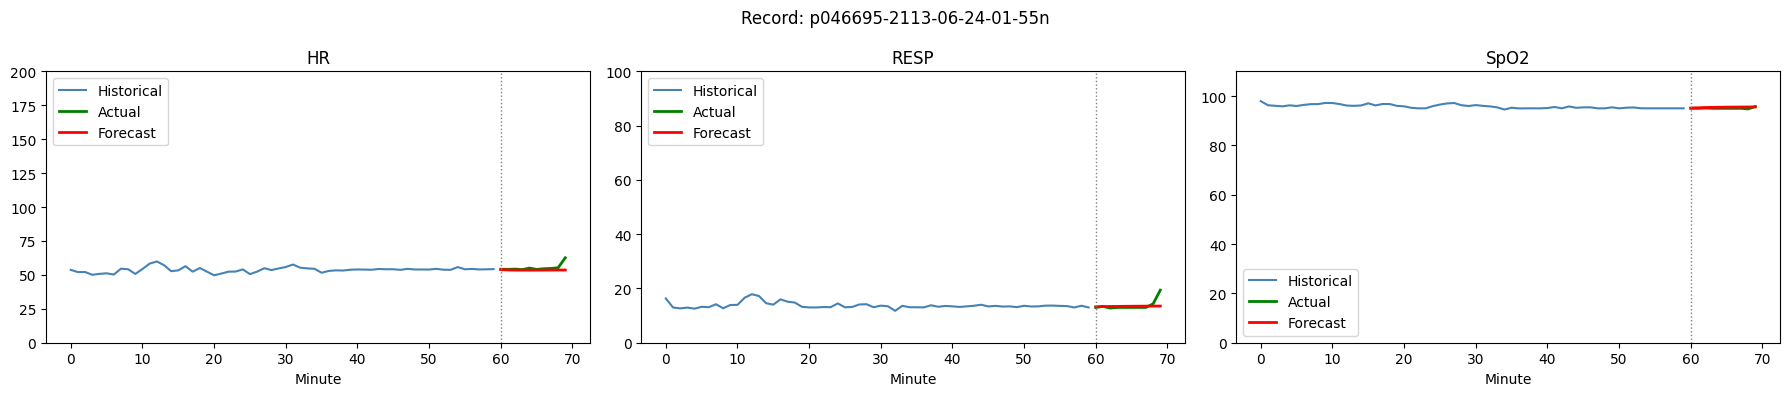

  p047266-2143-03-03-21-47n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p048915-2159-03-28-14-42n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p049649-2113-05-17-13-02n | lag=2 | AIC=1.6
    HR | MAE=2.440 | MAPE=4.052 | RMSE=3.152
    RESP | MAE=0.830 | MAPE=5.978 | RMSE=0.995
    SpO2 | MAE=1.257 | MAPE=1.280 | RMSE=1.368


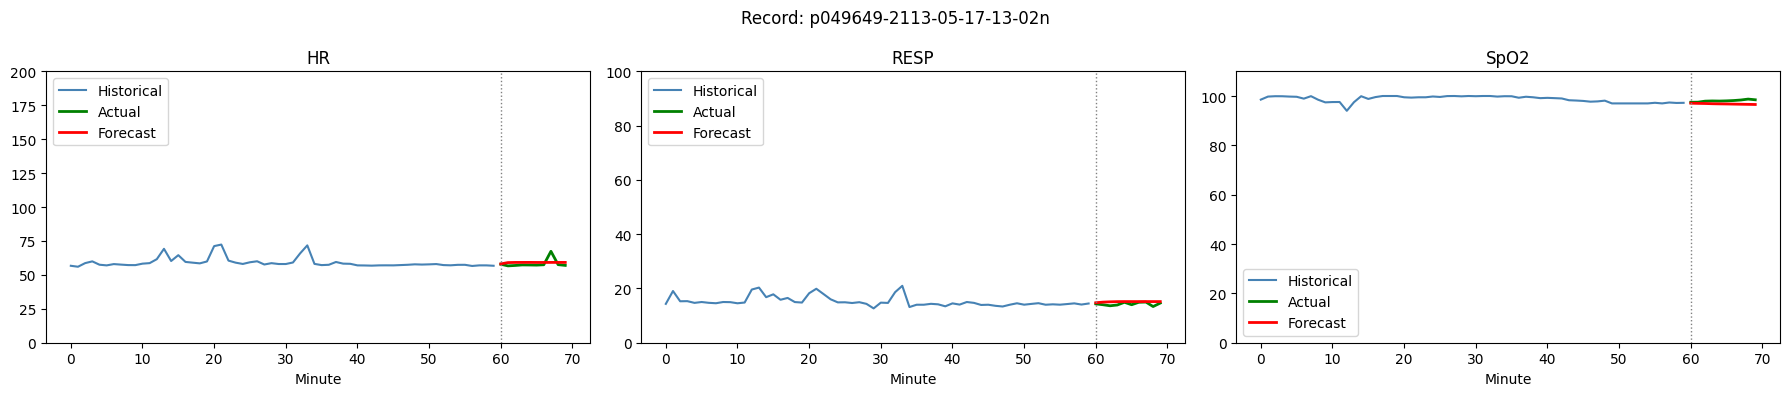

  p049650-2137-11-15-15-38n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p050178-2160-08-01-19-06n | Failed: 3-th leading minor of the array is not positive definite
  p052191-2193-11-24-02-42n | lag=5 | AIC=-0.0
    HR | MAE=4.060 | MAPE=5.079 | RMSE=4.511
    RESP | MAE=0.261 | MAPE=1.303 | RMSE=0.286
    SpO2 | MAE=0.086 | MAPE=0.086 | RMSE=0.098


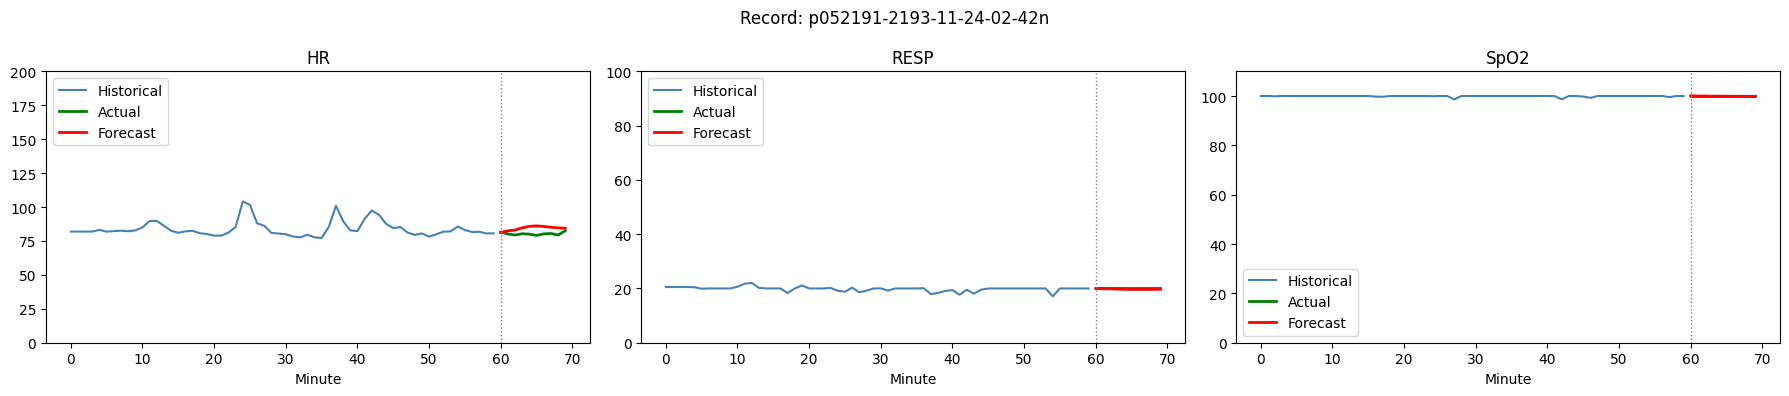

  p054675-2124-05-18-14-31n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p054736-2159-06-08-10-54n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p054900-2187-04-26-07-54n | Failed: 3-th leading minor of the array is not positive definite
  p054911-2166-01-14-17-54n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p055332-2193-03-27-15-40n | lag=2 | AIC=-0.1
    HR | MAE=1.052 | MAPE=1.358 | RMSE=1.192
    RESP | MAE=1.658 | MAPE=7.239 | RMSE=2.071
    SpO2 | MAE=0.381 | MAPE=0.393 | RMSE=0.527


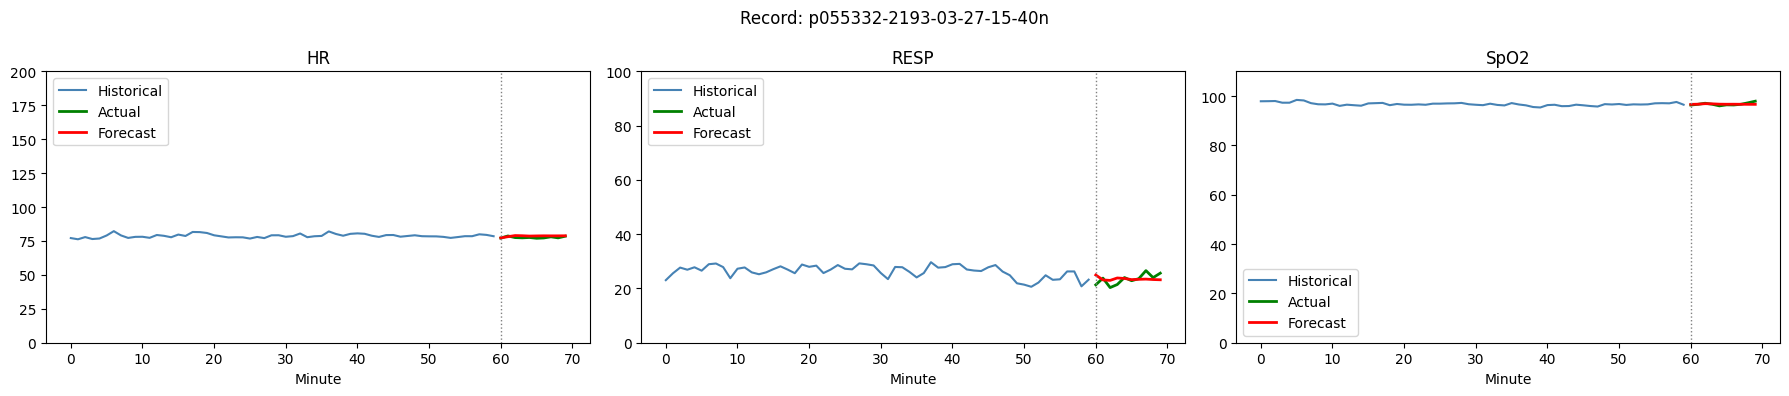

  p055886-2132-05-30-18-04n | Failed: 2-th leading minor of the array is not positive definite
  p055921-2179-08-17-07-17n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p057485-2174-02-10-09-38n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p058662-2120-01-08-20-54n | lag=2 | AIC=0.1
    HR | MAE=0.666 | MAPE=0.550 | RMSE=0.995
    RESP | MAE=1.561 | MAPE=5.160 | RMSE=1.749
    SpO2 | MAE=1.277 | MAPE=1.350 | RMSE=1.439


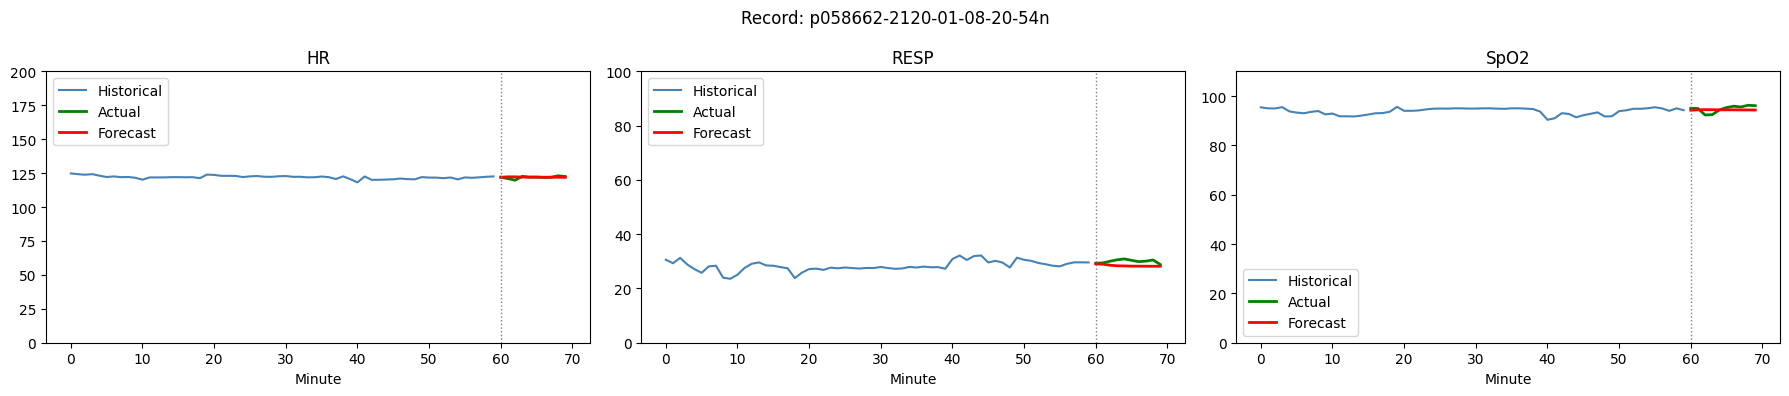

  p059199-2111-05-18-15-50n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p059347-2145-03-05-23-39n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p060226-2184-04-09-16-25n | lag=5 | AIC=-6.0
    HR | MAE=3.557 | MAPE=4.727 | RMSE=4.041
    RESP | MAE=0.164 | MAPE=1.357 | RMSE=0.198
    SpO2 | MAE=0.637 | MAPE=0.640 | RMSE=0.707


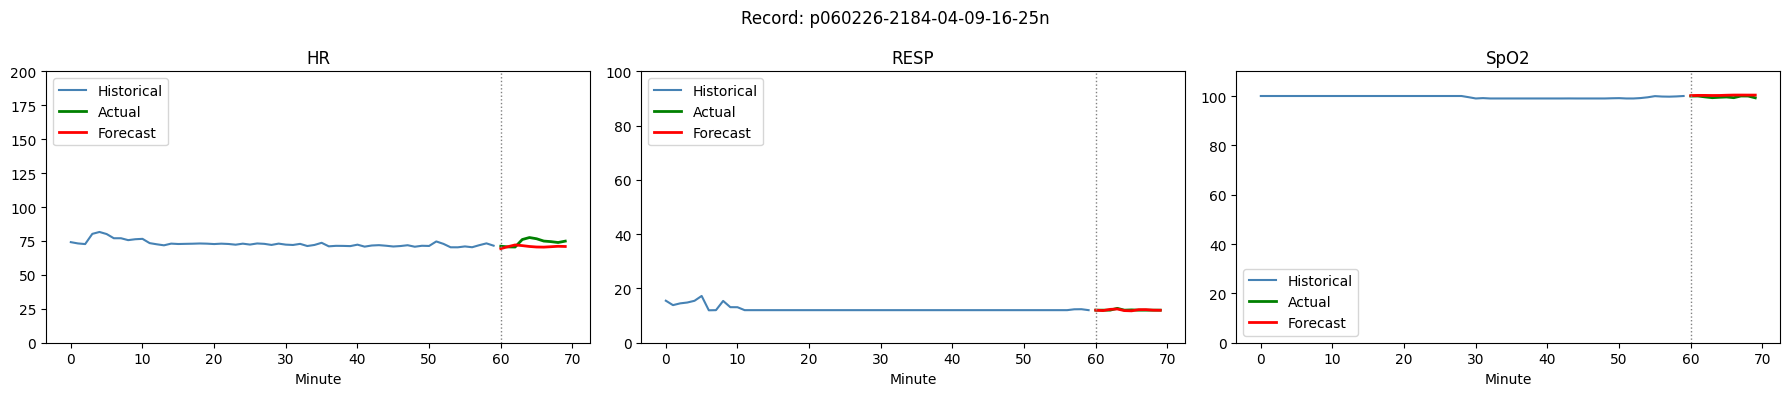

  p060226-2184-04-10-17-52n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p061195-2112-10-01-01-30n | Failed: 3-th leading minor of the array is not positive definite
  p062647-2143-06-03-14-10n | lag=1 | AIC=2.0
    HR | MAE=0.666 | MAPE=0.793 | RMSE=0.699
    RESP | MAE=1.263 | MAPE=7.350 | RMSE=1.482
    SpO2 | MAE=0.687 | MAPE=0.726 | RMSE=0.760


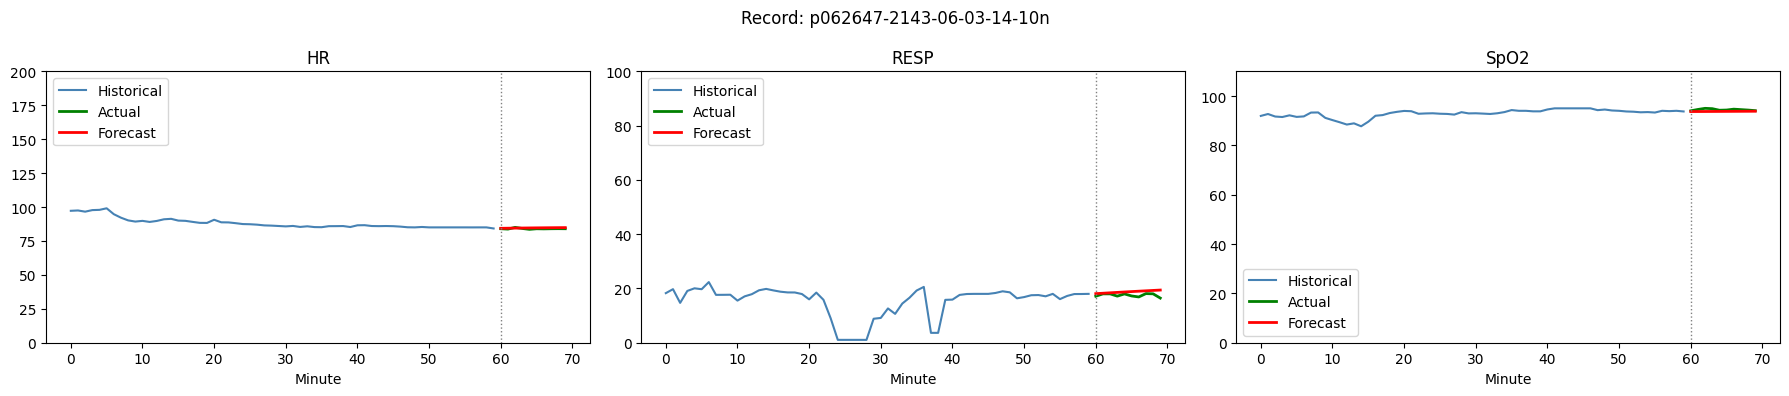

  p063017-2141-10-20-17-17n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p063559-2187-05-18-20-49n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p064361-2181-01-18-05-00n | lag=1 | AIC=7.3
    HR | MAE=1.357 | MAPE=1.577 | RMSE=1.906
    RESP | MAE=10.176 | MAPE=551.645 | RMSE=11.297
    SpO2 | MAE=0.839 | MAPE=0.841 | RMSE=0.989


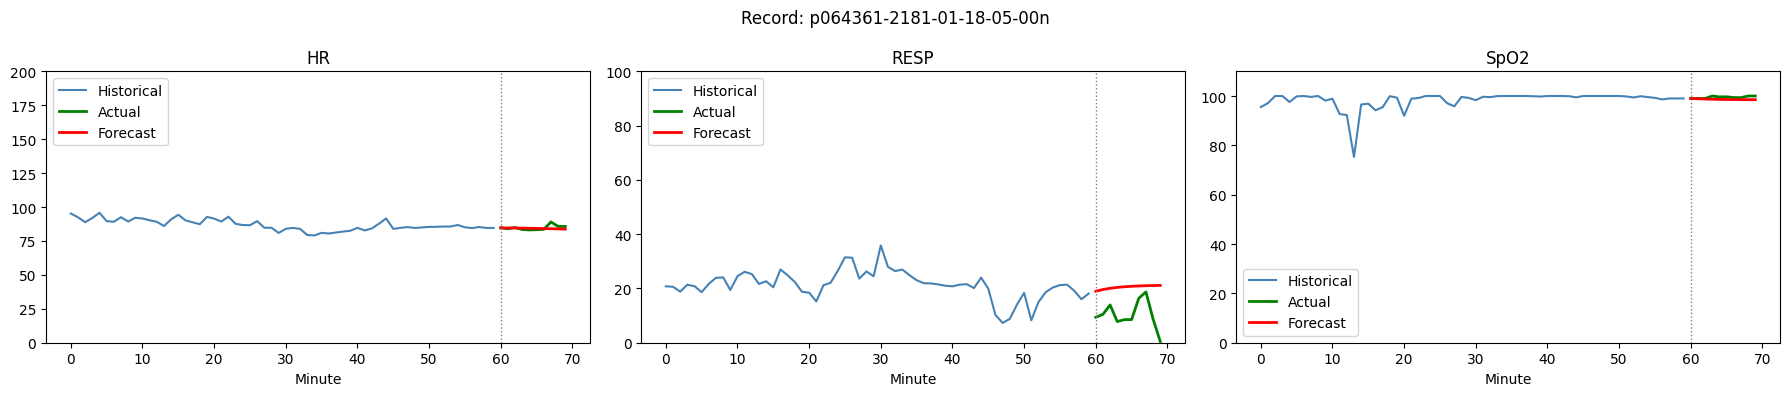

  p065404-2151-05-11-15-53n | Failed: 2-th leading minor of the array is not positive definite
  p065728-2120-02-15-14-23n | Failed: x contains one or more constant columns. Column(s) 5 are constant. Adding a constant with trend='c' is not allowed.
  p066786-2119-08-19-13-12n | lag=1 | AIC=4.0
    HR | MAE=2.539 | MAPE=2.822 | RMSE=3.037
    RESP | MAE=4.231 | MAPE=39.819 | RMSE=4.973
    SpO2 | MAE=1.429 | MAPE=1.432 | RMSE=1.464


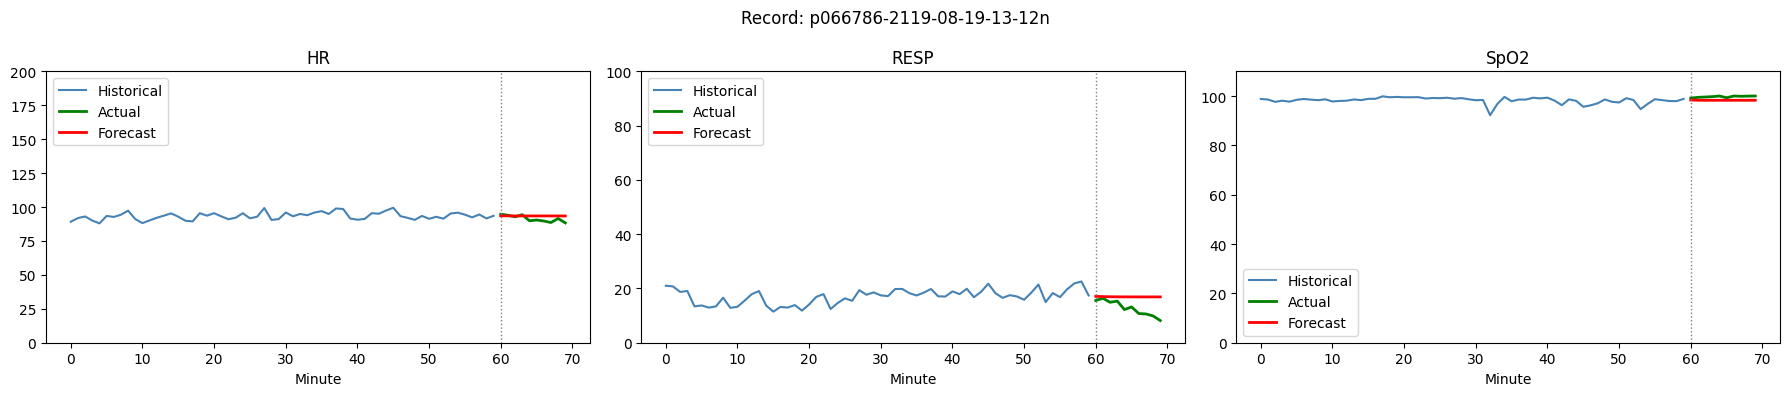

  p066892-2163-05-15-21-54n | Failed: 2-th leading minor of the array is not positive definite
  p067239-2165-09-18-14-07n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p068736-2113-12-08-10-43n | lag=1 | AIC=-0.1
    HR | MAE=0.810 | MAPE=1.032 | RMSE=0.879
    RESP | MAE=2.114 | MAPE=13.003 | RMSE=2.311
    SpO2 | MAE=0.819 | MAPE=0.862 | RMSE=1.097


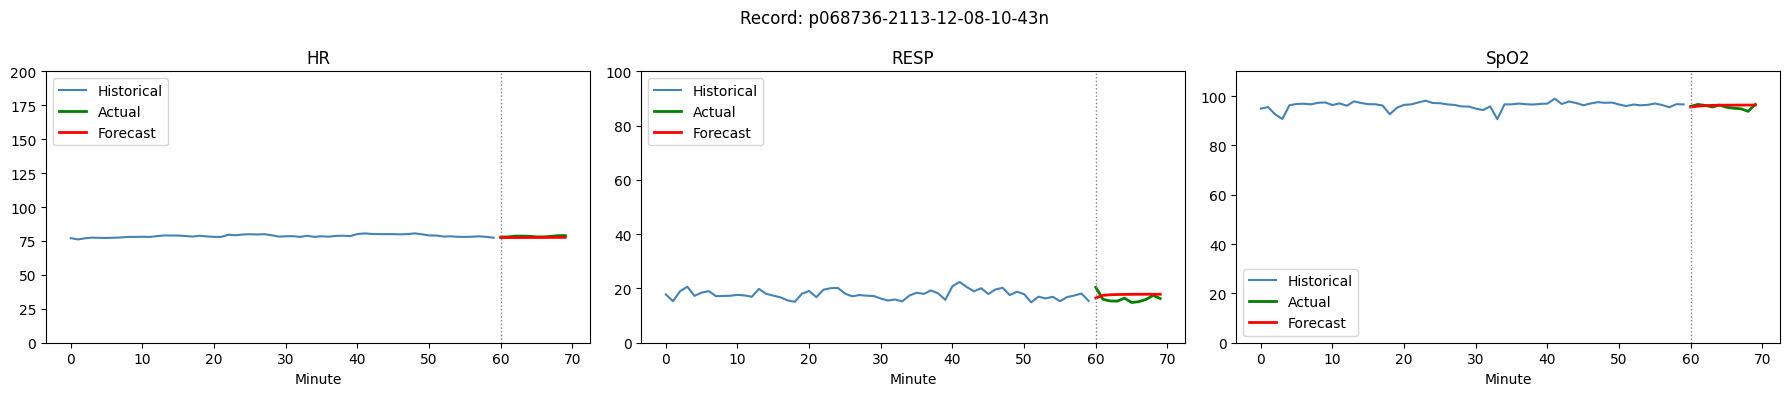

  p070494-2161-08-07-17-46n | Failed: 3-th leading minor of the array is not positive definite
  p071707-2144-01-21-10-52n | lag=1 | AIC=3.8
    HR | MAE=1.582 | MAPE=2.568 | RMSE=2.368
    RESP | MAE=1.332 | MAPE=9.313 | RMSE=1.617
    SpO2 | MAE=0.931 | MAPE=0.956 | RMSE=1.127


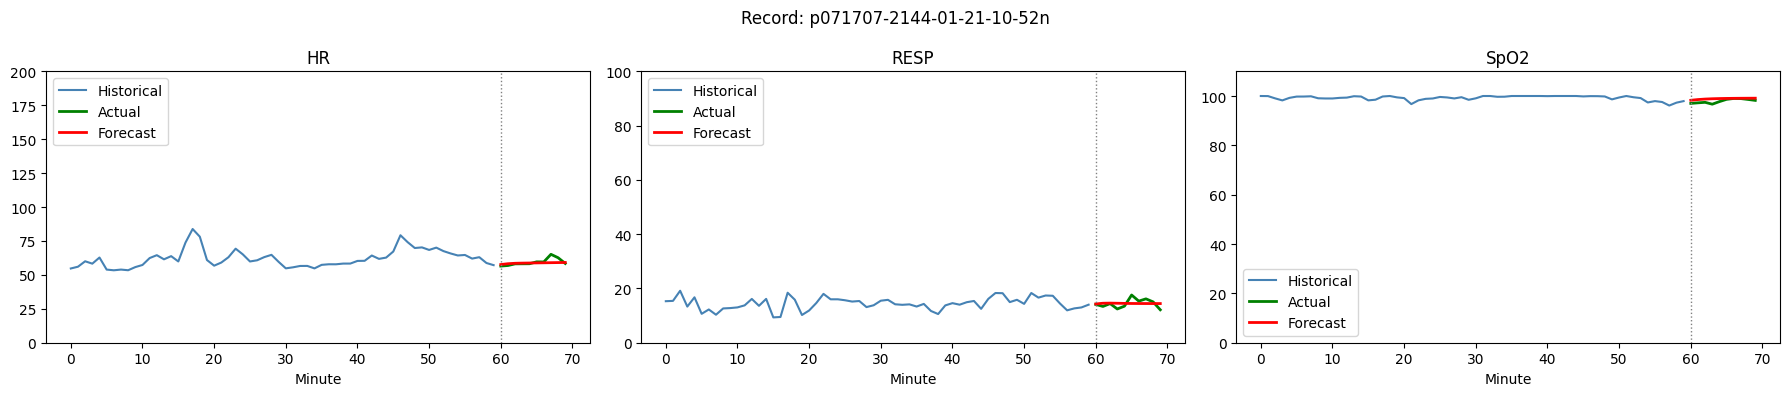

  p072248-2128-10-02-22-56n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p074397-2177-04-06-21-28n | lag=1 | AIC=4.3
    HR | MAE=3.645 | MAPE=4.510 | RMSE=3.971
    RESP | MAE=8.006 | MAPE=58.182 | RMSE=8.507
    SpO2 | MAE=0.412 | MAPE=0.420 | RMSE=0.498


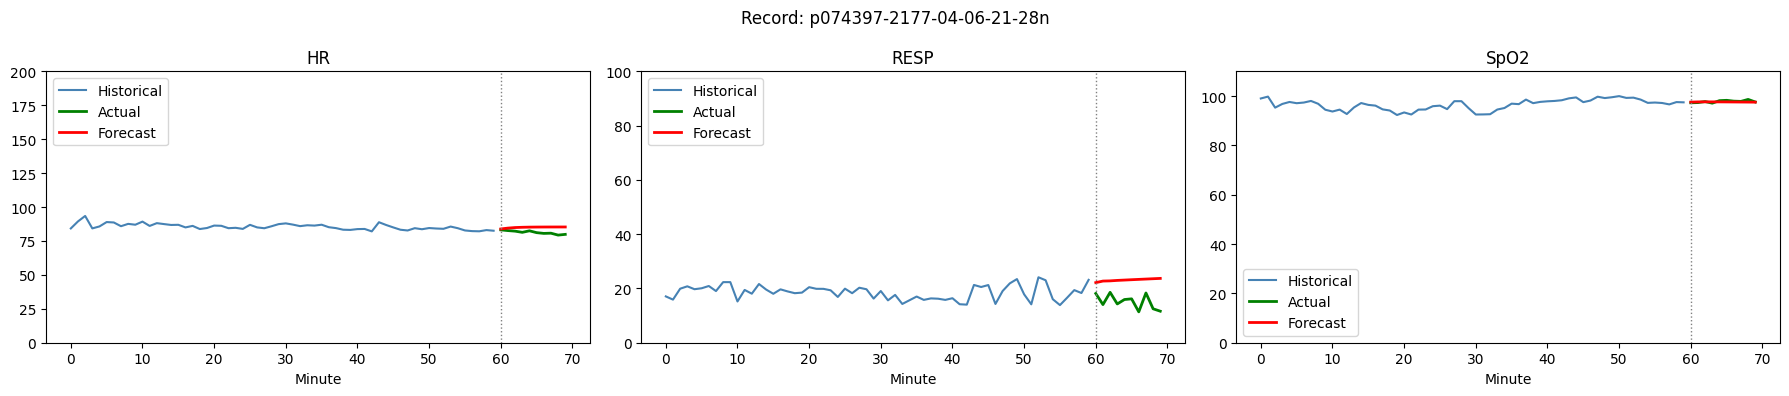

  p074438-2190-01-27-14-03n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p074618-2169-06-01-18-06n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p075023-2153-01-17-12-14n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p075347-2174-05-04-20-50n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p075347-2174-05-07-01-18n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p076028-2118-10-16-22-52n | lag=3 | AIC=-4.5
    HR | MAE=1.527 | MAPE=2.550 | RMSE=1.621
    RESP | MAE=0.352 | MAPE=2.201 | RMSE=0.363
    SpO2 | MAE=0.005 | MAPE=0.005 | RMSE=0.006


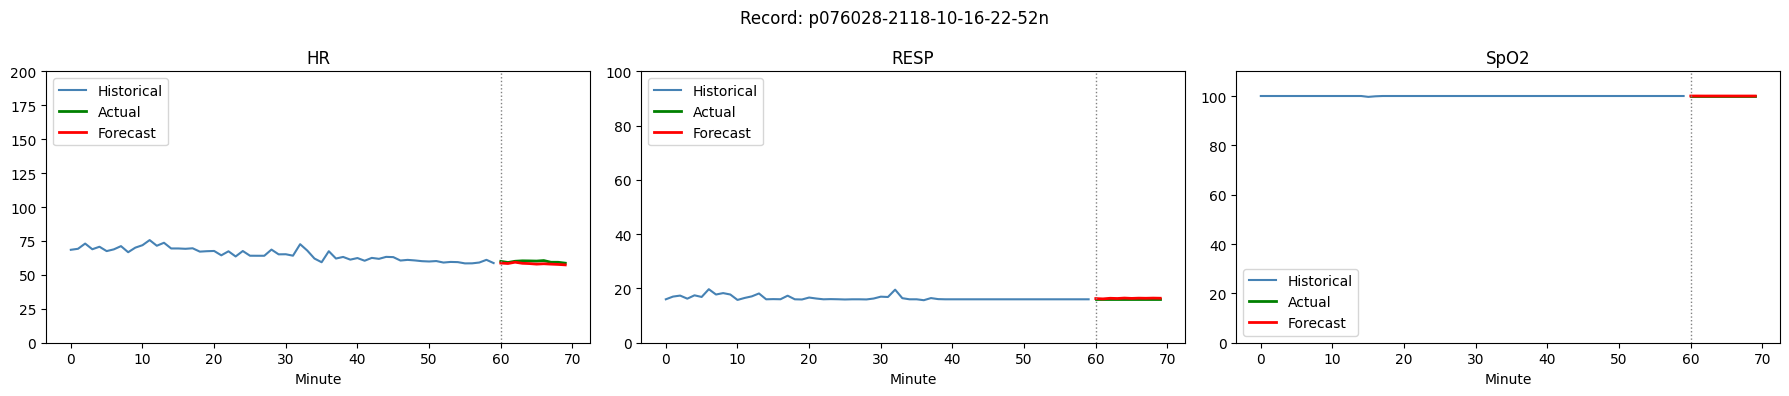

  p078506-2133-11-12-13-56n | lag=1 | AIC=3.2
    HR | MAE=1.519 | MAPE=1.650 | RMSE=1.802
    RESP | MAE=8.591 | MAPE=26.428 | RMSE=11.479
    SpO2 | MAE=0.323 | MAPE=0.326 | RMSE=0.376


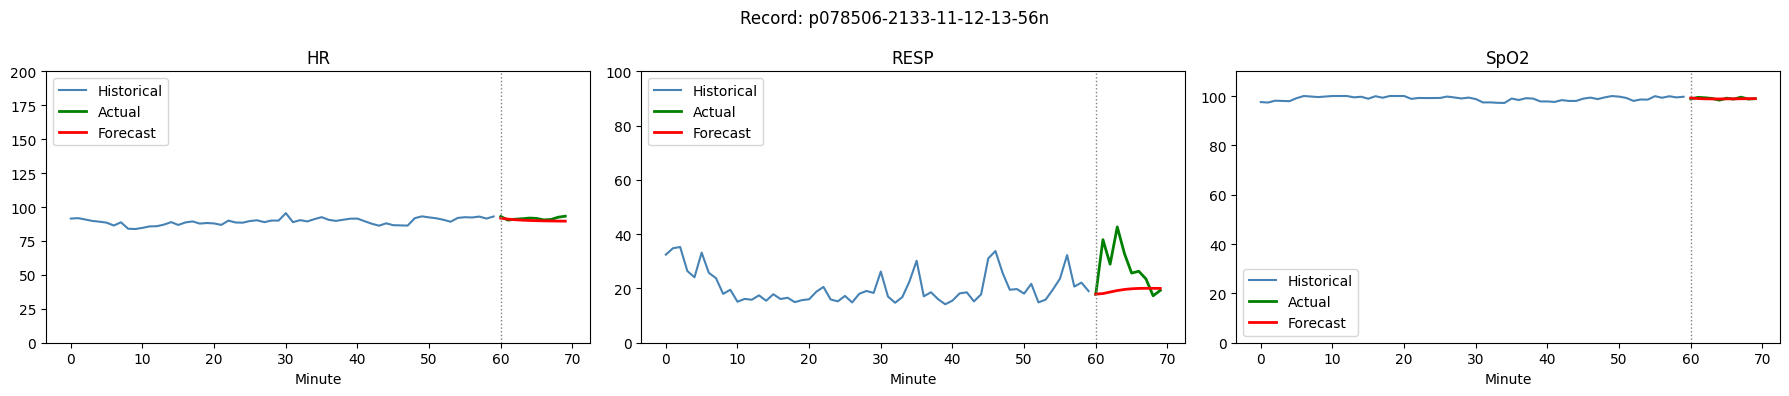

  p078556-2200-01-30-10-32n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p078979-2169-11-08-13-42n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p079422-2111-01-05-01-03n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p080423-2106-12-01-08-56n | Failed: 3-th leading minor of the array is not positive definite
  p081166-2103-12-18-18-01n | lag=3 | AIC=-6.3
    HR | MAE=3.177 | MAPE=3.385 | RMSE=3.408
    RESP | MAE=0.038 | MAPE=0.383 | RMSE=0.044
    SpO2 | MAE=0.142 | MAPE=0.145 | RMSE=0.216


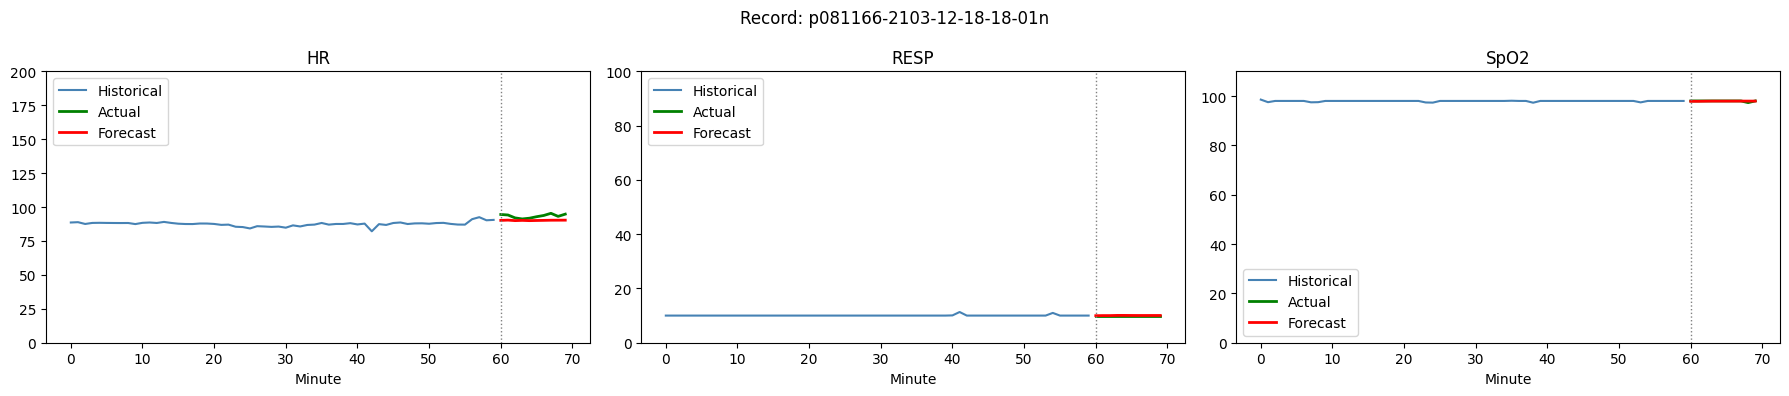

  p082433-2129-12-22-21-52n | Failed: x contains one or more constant columns. Column(s) 5 are constant. Adding a constant with trend='c' is not allowed.
  p082759-2137-09-02-11-44n | lag=1 | AIC=4.6
    HR | MAE=2.260 | MAPE=3.630 | RMSE=2.837
    RESP | MAE=0.917 | MAPE=5.298 | RMSE=1.089
    SpO2 | MAE=1.787 | MAPE=1.927 | RMSE=2.476


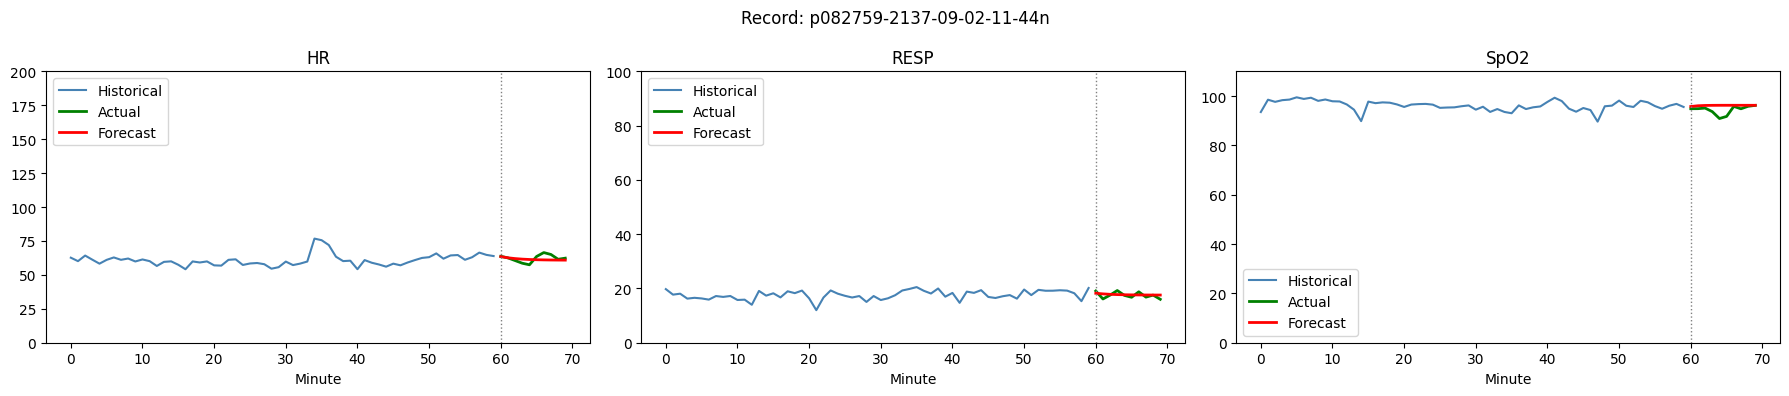

  p083065-2146-12-19-19-40n | Failed: x contains one or more constant columns. Column(s) 11 are constant. Adding a constant with trend='c' is not allowed.
  p083441-2134-05-06-14-31n | Failed: 3-th leading minor of the array is not positive definite
  p084042-2169-10-09-13-21n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p084392-2163-05-06-19-51n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p085205-2186-01-30-02-49n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p085976-2139-04-28-17-46n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p086976-2132-10-16-00-51n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend=

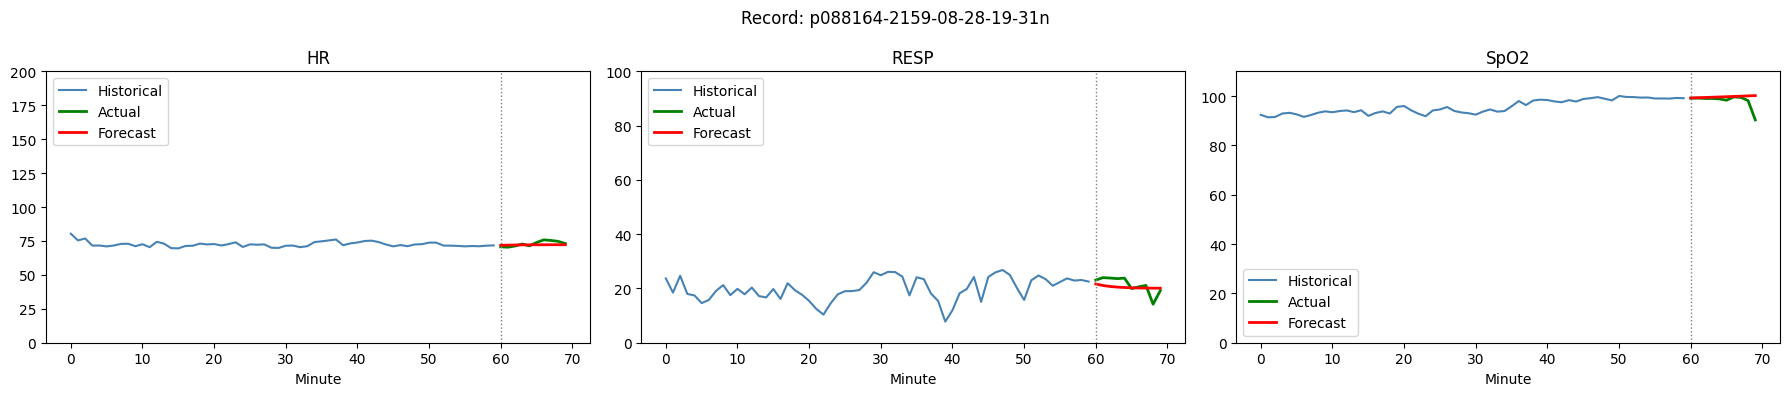

  p088175-2150-04-01-14-48n | Failed: 3-th leading minor of the array is not positive definite
  p090026-2114-10-10-10-48n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p090195-2201-03-28-01-21n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p090198-2129-11-09-08-23n | lag=1 | AIC=2.8
    HR | MAE=1.573 | MAPE=1.630 | RMSE=1.602
    RESP | MAE=1.800 | MAPE=12.515 | RMSE=1.931
    SpO2 | MAE=0.245 | MAPE=0.260 | RMSE=0.268


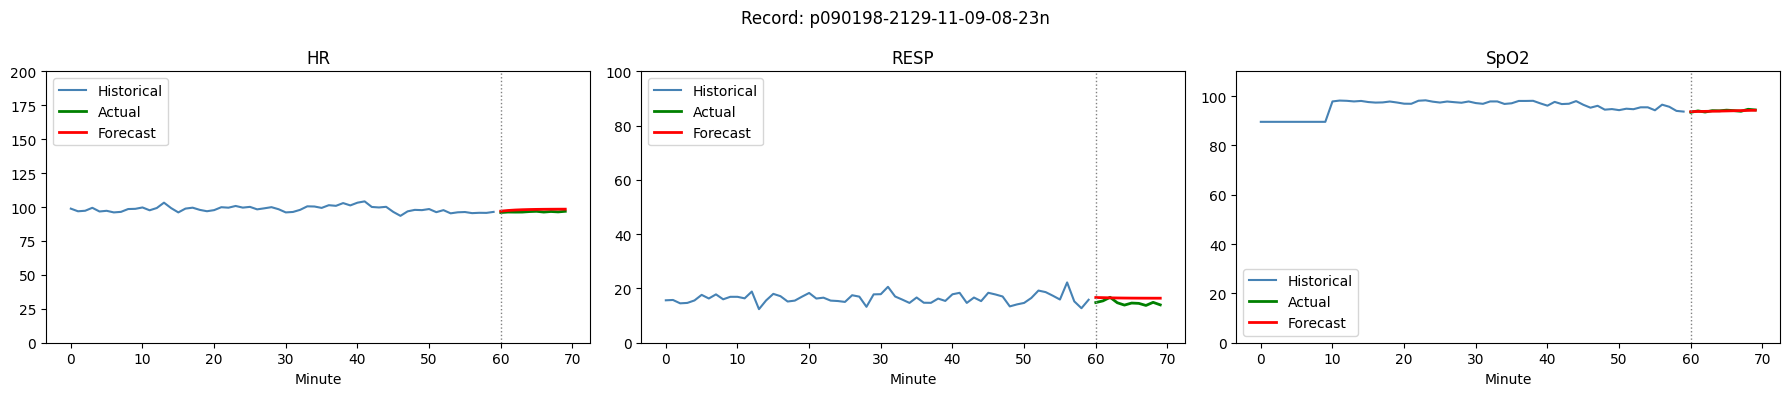

  p090208-2168-03-03-14-33n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p093033-2198-10-25-20-47n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p093301-2110-02-19-06-42n | lag=1 | AIC=5.5
    HR | MAE=2.456 | MAPE=1.675 | RMSE=3.101
    RESP | MAE=1.540 | MAPE=6.840 | RMSE=1.761
    SpO2 | MAE=1.912 | MAPE=2.055 | RMSE=2.094


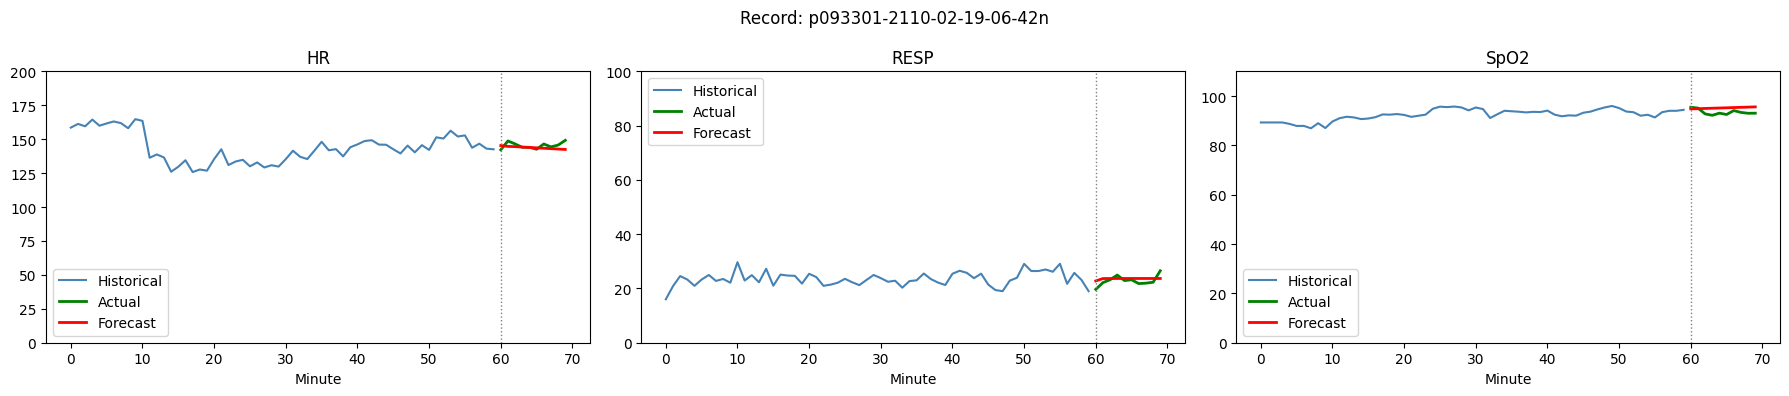

  p093718-2109-05-06-23-35n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p094300-2139-12-24-10-43n | Failed: x contains one or more constant columns. Column(s) 1 are constant. Adding a constant with trend='c' is not allowed.
  p095088-2189-11-04-13-39n | lag=1 | AIC=-6.1
    HR | MAE=0.787 | MAPE=0.936 | RMSE=0.968
    RESP | MAE=0.268 | MAPE=1.143 | RMSE=0.365
    SpO2 | MAE=0.005 | MAPE=0.005 | RMSE=0.006


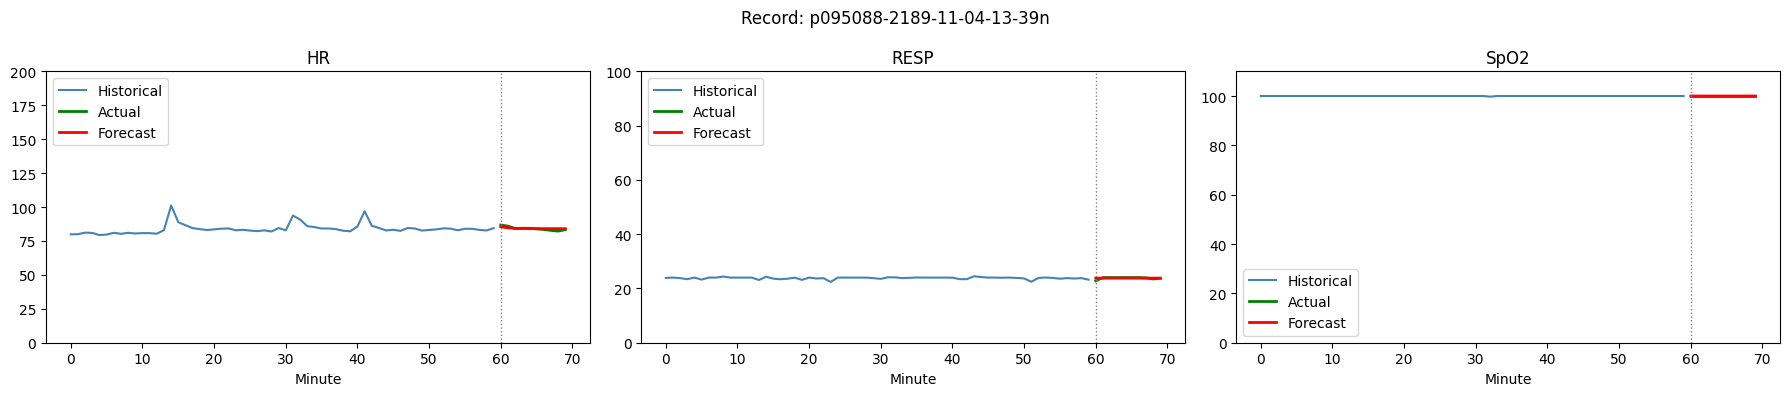

  p096592-2178-08-19-10-59n | Failed: 2-th leading minor of the array is not positive definite
  p097028-2101-10-22-06-33n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p097151-2131-08-30-11-49n | lag=1 | AIC=-0.0
    HR | MAE=0.735 | MAPE=1.277 | RMSE=0.821
    RESP | MAE=1.147 | MAPE=7.270 | RMSE=1.309
    SpO2 | MAE=0.184 | MAPE=0.185 | RMSE=0.212


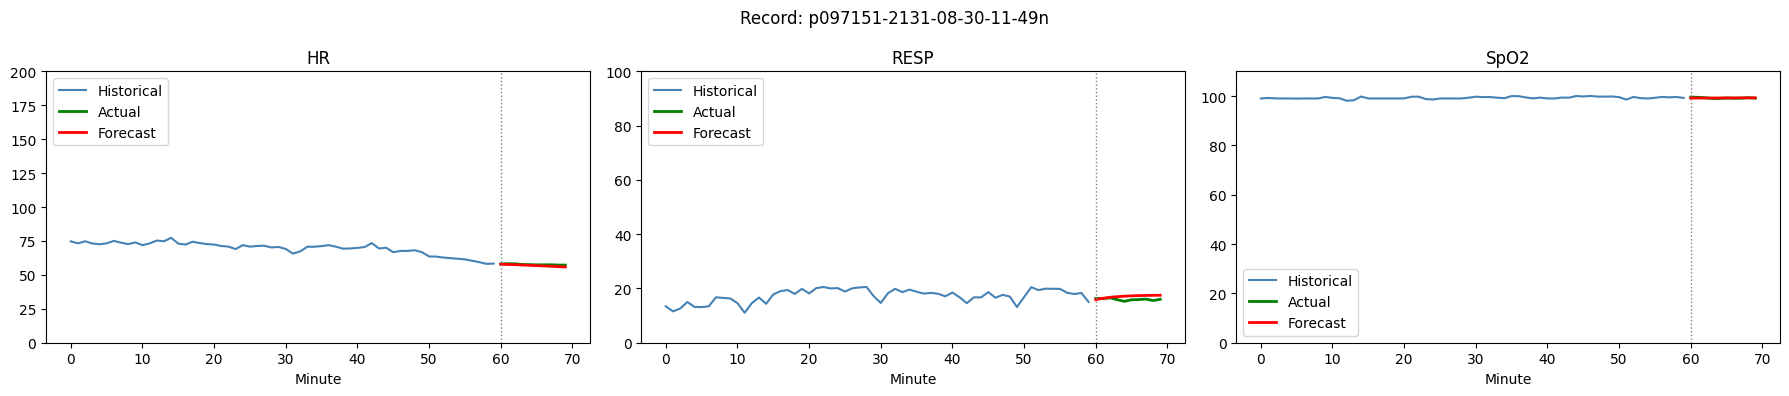

  p097158-2165-09-04-15-33n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p097307-2105-09-07-18-04n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p099286-2160-03-24-09-51n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p099599-2140-08-28-10-56n | Failed: x contains one or more constant columns. Column(s) 2 are constant. Adding a constant with trend='c' is not allowed.
  p099983-2193-04-26-12-01n | lag=1 | AIC=1.4
    HR | MAE=1.738 | MAPE=2.566 | RMSE=2.163
    RESP | MAE=1.185 | MAPE=6.504 | RMSE=1.658
    SpO2 | MAE=0.618 | MAPE=0.622 | RMSE=0.651


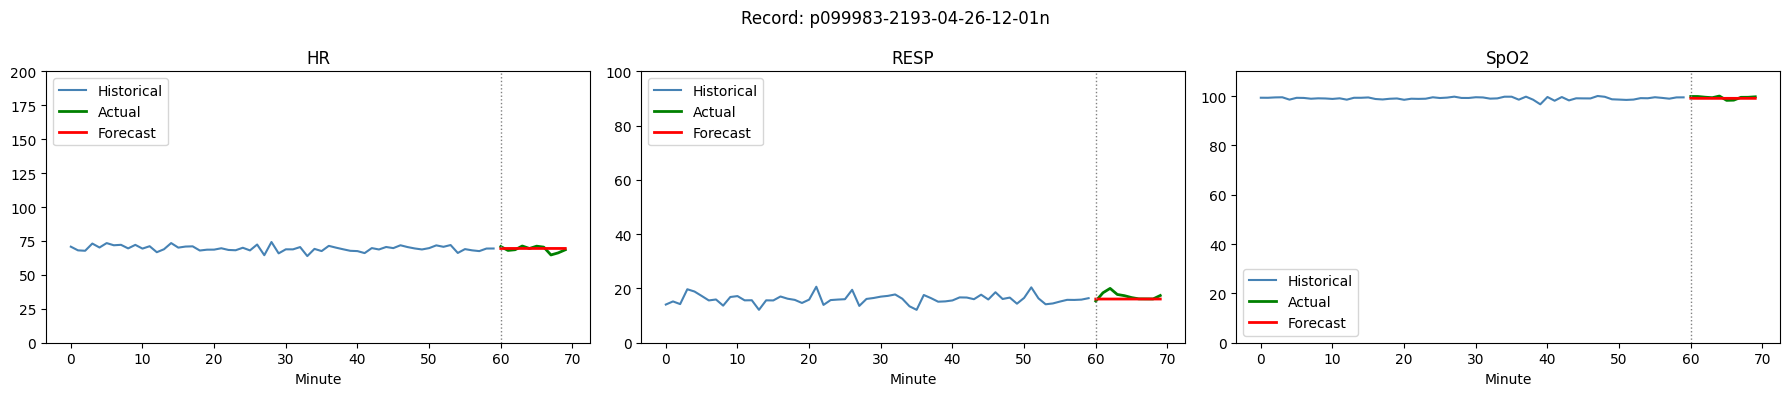

=== Alert Hit Rate by Vital ===
       Hits  Total HitRate
Vital                     
HR     1703   1816   93.8%
RESP   1049   1816   57.8%
SpO2   1518   1816   83.6%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.96      0.98      0.97      1550
     warning       0.84      0.67      0.75       218
   emergency       0.65      0.71      0.68        48

    accuracy                           0.94      1816
   macro avg       0.82      0.79      0.80      1816
weighted avg       0.94      0.94      0.94      1816


--- RESP ---
              precision    recall  f1-score   support

      stable       0.43      0.91      0.59       417
     warning       0.64      0.48      0.55       801
   emergency       0.85      0.47      0.61       598

    accuracy                           0.58      1816
   macro avg       0.64      0.62      0.58      1816
weighted avg       0.66      0.58      0.58      1816


---

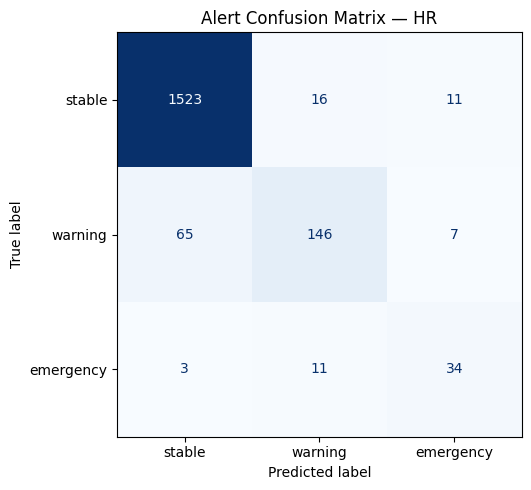

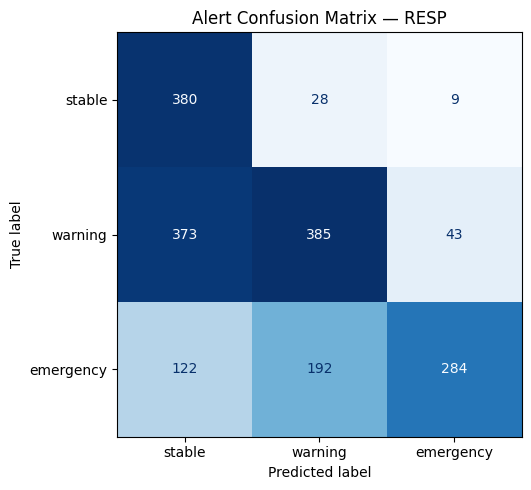

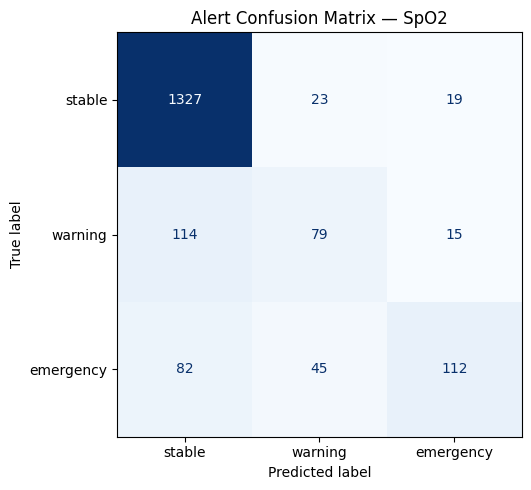


VAR MAE by vital:


,count,mean,std,min,25%,50%,75%,max
Vital,,,,,,,,
HR,1816.0,66.706592,1897.827076,0.003598,1.041935,1.898144,3.573645,66258.529843
RESP,1816.0,89.476015,2585.156011,0.001731,1.083555,1.769707,2.702010,85511.022791
SpO2,1816.0,196.524557,6212.852262,0.000159,0.286194,0.613659,1.196457,243730.262438


In [ ]:
warnings.filterwarnings('ignore')

TARGET_VITALS = ['HR', 'RESP', 'SpO2']
VITAL_YLIM = {
    'HR':   (0, 200),
    'RESP': (0, 100),
    'SpO2': (0, 110)
}

def make_stationary(train_df):
    """Difference any non-stationary series. Returns differenced df and dict of d per vital."""
    differenced = {}
    n_diffs = {}
    for col in train_df.columns:
        series = train_df[col]
        if series.nunique() <= 1 or adfuller(series)[1] <= 0.05:
            differenced[col] = series
            n_diffs[col] = 0
        else:
            differenced[col] = series.diff()
            n_diffs[col] = 1

    result = pd.DataFrame(differenced).dropna()
    return result, n_diffs

def undo_differencing(forecast, last_train_values, n_diffs):
    """Undo differencing to get back to original scale."""
    result = forecast.copy()
    for i, vital in enumerate(TARGET_VITALS):
        if n_diffs[vital] == 1:
            # cumsum from last known value
            result[:, i] = last_train_values[i] + np.cumsum(forecast[:, i])
    return result

def fit_and_evaluate_var(df, train_len=60, pred_len=10, delay=25, verbose=False):
    results = []
    alerts  = []
    record_count = 0

    for record, grp in df.groupby("Record"):
        grp = grp.sort_values("Minute").reset_index(drop=True)
        vital_plots = {}
        record_count += 1

        # Build multivariate series — all vitals together
        multi = grp[TARGET_VITALS].copy()
        for vital in TARGET_VITALS:
            multi[vital] = multi[vital].replace(0, np.nan).ffill().bfill()
        multi = multi.dropna()

        train_multi = multi.iloc[:train_len]
        test_multi  = multi.iloc[train_len:train_len + pred_len]

        if len(test_multi) < pred_len:
            continue

        try:
            train_stationary, n_diffs = make_stationary(train_multi)
            min_len = min(len(train_stationary[v]) for v in TARGET_VITALS)
            train_stationary = train_stationary.iloc[-min_len:]

            model     = VAR(train_stationary)
            lag_order = model.select_order(maxlags=5)
            best_lag  = max(1, lag_order.selected_orders['aic'])

            fitted   = model.fit(best_lag)
            forecast_diff = fitted.forecast(train_stationary.values[-best_lag:], steps=pred_len)

            last_train_values = train_multi.iloc[-1].values
            forecast = undo_differencing(forecast_diff, last_train_values, n_diffs)
            forecast_df = pd.DataFrame(forecast, columns=TARGET_VITALS)

            if verbose or record_count % 40 == 0:
                print(f"  {record} | lag={best_lag} | AIC={fitted.aic:.1f}")

            all_vitals_ok = True
            for vital in TARGET_VITALS:
                actuals  = test_multi[vital].values
                pred     = forecast_df[vital].values

                mae  = np.abs(pred - actuals).mean()
                rmse = np.sqrt(((pred - actuals) ** 2).mean())
                mask = actuals != 0
                mape = (np.abs((pred[mask] - actuals[mask]) / actuals[mask])).mean() * 100

                results.append({
                    "Record": record,
                    "Vital": vital,
                    "Lag": best_lag,
                    "MAE": mae,
                    "RMSE": rmse,
                    "MAPE": mape
                })

                alert_result = evaluate_alert_hitrate(pred, actuals, vital)
                alert_result["Record"] = record
                alerts.append(alert_result)

                vital_plots[vital] = (train_multi[vital], actuals, pred)

                if verbose or record_count % 40 == 0:
                    print(f"    {vital} | MAE={mae:.3f} | MAPE={mape:.3f} | RMSE={rmse:.3f}")

        except Exception as e:
            all_vitals_ok = False
            print(f"  {record} | Failed: {e}")
            continue

        if all_vitals_ok and record_count % 40 == 0:
            fig, axes = plt.subplots(1, 3, figsize=(18, 4))
            fig.suptitle(f"Record: {record}", fontsize=12)

            for ax, vital in zip(axes, TARGET_VITALS):
                train_series, actuals, forecast_vals = vital_plots[vital]
                train_x    = np.arange(len(train_series))
                forecast_x = np.arange(len(train_series), len(train_series) + pred_len)

                ax.plot(train_x,    train_series.values, color='steelblue', label='Historical')
                ax.plot(forecast_x, actuals,             color='green',     label='Actual',    linewidth=2)
                ax.plot(forecast_x, forecast_vals,       color='red',       label='Forecast',  linewidth=2)
                ax.axvline(x=len(train_series), color='gray', linestyle=':', linewidth=1)
                ax.set_title(vital)
                ax.set_xlabel("Minute")
                ax.set_ylim(VITAL_YLIM[vital])
                ax.legend()

            plt.tight_layout()
            plt.show()

    return pd.DataFrame(results), summarize_alert_hitrate(alerts)

results_df, alerts_df = fit_and_evaluate_var(sampled_df, train_len=60, pred_len=10, delay=25, verbose=False)

print("\nVAR MAE by vital:")
results_df.groupby("Vital")["MAE"].describe()

In [6]:
results_df.groupby("Vital")["MAE"].describe()[['mean', 'std', '50%']]

,mean,std,50%
Vital,,,
HR,66.706592,1897.827076,1.898144
RESP,89.476015,2585.156011,1.769707
SpO2,196.524557,6212.852262,0.613659


In [7]:
results_df.to_csv("var_results.csv", index=False)

In [8]:
alerts_df.to_csv("var_results_alerts.csv", index=False)